# TalkEx: Experimental Evaluation of a Hybrid Cascaded Architecture for Conversation Intent Classification

**Dissertation Appendix — Complete Experimental Notebook**

**Author:** Paulo Richard Sakaguchi
**Program:** Master's in Computer Science
**Date:** March 2026

---

## Abstract

This notebook contains the **complete, reproducible experimental evaluation** for the TalkEx dissertation.
It implements and validates four hypotheses about hybrid NLP architectures for conversation intent classification:

| Hypothesis | Claim |
|:---|:---|
| **H1** | Hybrid retrieval (BM25 + ANN) outperforms isolated paradigms |
| **H2** | Multi-level features (lexical + embeddings) improve classification over lexical-only |
| **H3** | Deterministic rules complement ML classifiers |
| **H4** | Cascaded inference reduces cost without sacrificing quality |

Plus ablation studies, stratified k-fold cross-validation, leave-one-domain-out evaluation,
and comprehensive error analysis.

### Reproducibility Statement

Every result in this notebook is deterministic given:
- The dataset splits in `experiments/data/`
- The random seeds `[13, 42, 123, 2024, 999]`
- The package versions logged in §1

**Designed for Google Colab.** The first cell clones the repository and installs all dependencies.
No local setup required — just click "Run All".

---

## Table of Contents

1. [Environment & Reproducibility](#§1)
2. [Dataset Characterization](#§2)
3. [Experimental Protocol](#§3)
4. [H1 — Hybrid Retrieval](#§4)
5. [H2 — Multi-Level Classification](#§5)
6. [H3 — Rules Complement ML](#§6)
7. [H4 — Cascaded Inference](#§7)
8. [Ablation Studies](#§8)
9. [Stratified K-Fold Cross-Validation](#§9)
10. [Leave-One-Domain-Out (LODO)](#§10)
11. [Error Analysis & Interpretability](#§11)
12. [Statistical Summary & Hypothesis Decisions](#§12)
13. [Limitations & Threats to Validity](#§13)


<a id="§1"></a>
## §1. Environment & Reproducibility

We log the complete computational environment to ensure full reproducibility.
All experiments use the same embedding model, classifier configurations, and random seeds.

**Principle:** *Any researcher with access to this repository must be able to reproduce
every number in this notebook by running it end-to-end.*


In [24]:
# ---------------------------------------------------------------------------
# §1.0 — Environment Setup: Clone repository and install dependencies
# ---------------------------------------------------------------------------
# Detects Google Colab vs local execution automatically.
# On Colab: clones the repo, checks out the experiment branch, installs deps.
# Locally: skips (assumes project is already set up).
#
# Idempotent: safe to re-run. If repo exists, pulls latest changes.
# ---------------------------------------------------------------------------
import os
import subprocess
import sys

IS_COLAB = "COLAB_RELEASE_TAG" in os.environ or (
    os.path.exists("/content") and os.path.exists("/usr/local/lib/python3")
)

# Branch containing experiment data and results
EXPERIMENT_BRANCH = "feat/experiment-results-preliminary"

if IS_COLAB:
    REPO_URL = "https://github.com/paulohenriquevn/semantic-text-classification.git"
    REPO_DIR = "/content/semantic-text-classification"

    if os.path.exists(REPO_DIR):
        print(f"Repository already cloned at {REPO_DIR}")
        os.chdir(REPO_DIR)
    else:
        print(f"Cloning {REPO_URL} (branch: {EXPERIMENT_BRANCH}) ...")
        subprocess.run(
            ["git", "clone", "-b", EXPERIMENT_BRANCH, REPO_URL, REPO_DIR],
            check=True,
        )
        os.chdir(REPO_DIR)

    # Ensure we are on the correct branch (data + results live here)
    current_branch = subprocess.check_output(
        ["git", "branch", "--show-current"], text=True
    ).strip()
    if current_branch != EXPERIMENT_BRANCH:
        print(f"Switching from '{current_branch}' to '{EXPERIMENT_BRANCH}'...")
        subprocess.run(["git", "fetch", "origin", EXPERIMENT_BRANCH], check=True)
        # Discard local changes (Colab workspace is ephemeral) and switch
        subprocess.run(["git", "stash", "--include-untracked"], check=False)
        subprocess.run(
            ["git", "switch", "-f", EXPERIMENT_BRANCH], check=True,
        )
    print(f"Branch: {EXPERIMENT_BRANCH}")

    # Pull latest changes
    subprocess.run(["git", "pull", "--ff-only"], check=False)

    # Add source paths BEFORE pip install — ensures talkex is importable
    # even if pip install is interrupted or slow.
    for sub in ["src", "experiments/scripts", "experiments"]:
        p = os.path.join(REPO_DIR, sub)
        if p not in sys.path:
            sys.path.insert(0, p)

    print(f"Working directory: {os.getcwd()}")

    # Verify critical data files exist
    data_dir = os.path.join(REPO_DIR, "experiments", "data")
    missing = [f for f in ["train.jsonl", "val.jsonl", "test.jsonl"]
               if not os.path.exists(os.path.join(data_dir, f))]
    if missing:
        print(f"ERROR: Missing data files: {missing}")
        print(f"Check that branch '{EXPERIMENT_BRANCH}' contains experiments/data/")
        raise FileNotFoundError(f"Missing data files: {missing}")
    print(f"Data files: OK ({len(os.listdir(data_dir))} files)")

    print("\nInstalling TalkEx and dependencies...")
    result = subprocess.run(
        ["pip", "install", "-e", ".", "-q"],
        cwd=REPO_DIR,
        capture_output=True,
        text=True,
        timeout=300,
    )
    if result.returncode == 0:
        print("Installation complete.")
    else:
        print("WARNING: pip install failed. Stderr (last 1000 chars):")
        print(result.stderr[-1000:] if result.stderr else "(no stderr)")
        print("\nContinuing with sys.path fallback.")
        print("Most dependencies (numpy, pandas, sklearn, etc.) are pre-installed on Colab.")
else:
    print("Local environment detected — skipping clone/install.")
    print(f"Working directory: {os.getcwd()}")

Repository already cloned at /content/semantic-text-classification
Branch: feat/experiment-results-preliminary
Working directory: /content/semantic-text-classification
Data files: OK (11 files)

Installing TalkEx and dependencies...
Installation complete.


In [25]:
import json
import os
import platform
import subprocess
import sys
import time
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# ---------------------------------------------------------------------------
# Path setup — resolve PROJECT_ROOT from cloned repo
# ---------------------------------------------------------------------------
# On Google Colab the repo is cloned to /content/semantic-text-classification
# by the setup cell above. Locally, fall back to cwd heuristics.
_COLAB_ROOT = Path("/content/semantic-text-classification")
if _COLAB_ROOT.exists() and (_COLAB_ROOT / "src" / "talkex").exists():
    PROJECT_ROOT = _COLAB_ROOT
elif (Path.cwd() / "src" / "talkex").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd().parent.parent
    assert (PROJECT_ROOT / "src" / "talkex").exists(), (
        "Could not find project root. Clone the repo or run from the project directory."
    )

os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "experiments" / "scripts"))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = PROJECT_ROOT / "experiments" / "data"

# Seeds (standardized, post-audit)
SEEDS = [13, 42, 123, 2024, 999]

# ---------------------------------------------------------------------------
# Publication-quality matplotlib style
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "font.size": 11,
    "font.family": "serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Colorblind-friendly palette
PALETTE = sns.color_palette("colorblind")
COLORS = {
    "primary": PALETTE[0],
    "secondary": PALETTE[1],
    "tertiary": PALETTE[2],
    "quaternary": PALETTE[3],
    "highlight": PALETTE[4],
    "muted": PALETTE[7],
}

print("Environment initialized successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

# --- Warning suppression audit trail (MN-1) ---
_suppressed = ["FutureWarning (all modules)", "UserWarning (lightgbm)"]
print(f"Suppressed warnings: {', '.join(_suppressed)}")
print("These are cosmetic deprecation/verbosity warnings; no impact on results.")
# --- Warning suppression audit trail (MN-1) ---
_suppressed = ["FutureWarning (all modules)", "UserWarning (lightgbm)"]
print(f"Suppressed warnings: {', '.join(_suppressed)}")
print("These are cosmetic deprecation/verbosity warnings; no impact on results.")

Environment initialized successfully.
Project root: /content/semantic-text-classification
Results dir:  /content/semantic-text-classification/experiments/results
Figures dir:  /content/semantic-text-classification/experiments/results/figures
Suppressed warnings: FutureWarning (all modules), UserWarning (lightgbm)
These are cosmetic deprecation/verbosity warnings; no impact on results.
Suppressed warnings: FutureWarning (all modules), UserWarning (lightgbm)
These are cosmetic deprecation/verbosity warnings; no impact on results.


In [26]:
# ---------------------------------------------------------------------------
# Reproducibility manifest
# ---------------------------------------------------------------------------
def get_git_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL
        ).decode().strip()[:12]
    except Exception:
        return "unknown"

def get_package_versions():
    packages = {
        "numpy": "numpy",
        "pandas": "pandas",
        "scikit-learn": "sklearn",
        "lightgbm": "lightgbm",
        "matplotlib": "matplotlib",
        "seaborn": "seaborn",
        "scipy": "scipy",
        "sentence-transformers": "sentence_transformers",
        "torch": "torch",
        "pydantic": "pydantic",
    }
    versions = {}
    for display_name, import_name in packages.items():
        try:
            mod = __import__(import_name)
            versions[display_name] = getattr(mod, "__version__", "?")
        except ImportError:
            versions[display_name] = "not installed"
    return versions

manifest = {
    "timestamp": datetime.now().isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "cpu": platform.processor() or "unknown",
    "git_commit": get_git_hash(),
    "seeds": SEEDS,
    "embedding_model": "paraphrase-multilingual-MiniLM-L12-v2",
    "embedding_dims": 384,
    "classifier": "LightGBM (n_estimators=100, num_leaves=31)",
    "window_config": "5-turn windows, stride=2",
    "packages": get_package_versions(),
}

print("=" * 60)
print("REPRODUCIBILITY MANIFEST")
print("=" * 60)
for k, v in manifest.items():
    if k == "packages":
        print(f"\n  Package versions:")
        for pkg, ver in v.items():
            print(f"    {pkg:25s} {ver}")
    else:
        print(f"  {k:20s} {v}")
print("=" * 60)

# Save manifest
manifest_path = FIGURES_DIR / "reproducibility_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nManifest saved to {manifest_path}")


REPRODUCIBILITY MANIFEST
  timestamp            2026-03-13T19:21:04.133365
  python               3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
  platform             Linux-6.6.113+-x86_64-with-glibc2.35
  cpu                  x86_64
  git_commit           c45b790ced8a
  seeds                [13, 42, 123, 2024, 999]
  embedding_model      paraphrase-multilingual-MiniLM-L12-v2
  embedding_dims       384
  classifier           LightGBM (n_estimators=100, num_leaves=31)
  window_config        5-turn windows, stride=2

  Package versions:
    numpy                     2.0.2
    pandas                    2.2.2
    scikit-learn              1.6.1
    lightgbm                  4.6.0
    matplotlib                3.10.0
    seaborn                   0.13.2
    scipy                     1.16.3
    sentence-transformers     5.2.3
    torch                     2.10.0+cpu
    pydantic                  2.12.3

Manifest saved to /content/semantic-text-classification/experiments/results/figures/

In [27]:
# ---------------------------------------------------------------------------
# TalkEx Pipeline Validation
# ---------------------------------------------------------------------------
# Validates that the TalkEx package is importable and all core NLP modules
# used by the experiment pipeline are available.

import importlib

import talkex
print(f"TalkEx version: {talkex.__version__}")
print(f"Package location: {talkex.__file__}")
print()

# Core modules exercised by the experiment pipeline (run_experiment.py)
CORE_MODULES = {
    "talkex.ingestion":          "Data loading and format handling",
    "talkex.segmentation":       "Turn segmentation and normalization",
    "talkex.context":            "Sliding window builder for multi-turn context",
    "talkex.embeddings":         "Embedding generation (MiniLM-L12-v2, 384d)",
    "talkex.retrieval":          "Hybrid search: BM25 + ANN + score fusion (H1)",
    "talkex.classification":     "LightGBM, LogReg, MLP classifiers (H2-H4)",
    "talkex.rules":              "Semantic rule engine: DSL → AST → eval (H3)",
    "talkex.evaluation":         "Metrics: MRR, nDCG, Recall@K, F1",
    "talkex.text_normalization": "Text normalization for lexical matching",
    "talkex.models":             "Domain types: Conversation, Turn, ContextWindow",
}

print(f"Validating {len(CORE_MODULES)} core pipeline modules...")
print(f"{'Module':35s} {'Status':10s} Description")
print("-" * 90)

all_ok = True
for module_name, description in CORE_MODULES.items():
    try:
        mod = importlib.import_module(module_name)
        print(f"{module_name:35s} {'OK':10s} {description}")
    except ImportError as e:
        print(f"{module_name:35s} {'MISSING':10s} {description}  -- {e}")
        all_ok = False

print("-" * 90)
if all_ok:
    print(f"All {len(CORE_MODULES)} core modules validated successfully.")
    print("The experiment results in this notebook were produced by these modules.")
else:
    print("WARNING: Some modules are missing. Results may not be reproducible.")
    print("Run: pip install -e . from the project root.")


TalkEx version: 0.1.0
Package location: /content/semantic-text-classification/src/talkex/__init__.py

Validating 10 core pipeline modules...
Module                              Status     Description
------------------------------------------------------------------------------------------
talkex.ingestion                    OK         Data loading and format handling
talkex.segmentation                 OK         Turn segmentation and normalization
talkex.context                      OK         Sliding window builder for multi-turn context
talkex.embeddings                   OK         Embedding generation (MiniLM-L12-v2, 384d)
talkex.retrieval                    OK         Hybrid search: BM25 + ANN + score fusion (H1)
talkex.classification               OK         LightGBM, LogReg, MLP classifiers (H2-H4)
talkex.rules                        OK         Semantic rule engine: DSL → AST → eval (H3)
talkex.evaluation                   OK         Metrics: MRR, nDCG, Recall@K, F1
talkex.tex

<a id="§2"></a>
## §2. Dataset Characterization

### 2.1 Dataset Overview

The TalkEx dataset consists of **2,122 PT-BR customer service conversations** across 8 intent classes
and 8 business domains, post-audit (deduplication, leakage remediation, taxonomy cleanup).

**Source:** `RichardSakaguchiMS/brazilian-customer-service-conversations` (Apache 2.0)
**Composition:** 847 original + 1,275 LLM-synthetic conversations
**Pre-processing:** The "outros" (other) class was removed during audit as it conflated
genuinely ambiguous conversations with labeling errors.

### 2.2 Split Strategy

Contamination-aware splitting ensures no near-duplicate conversations leak across splits.
The 60/20/20 train/val/test ratio follows standard practice.


In [28]:
# ---------------------------------------------------------------------------
# Dataset loading utilities (inlined to avoid pulling run_experiment.py's
# heavy TalkEx imports, which fail if pip install was incomplete on Colab)
# ---------------------------------------------------------------------------
def load_split(split_name: str, data_dir: Path) -> list:
    """Load a JSONL split file."""
    path = data_dir / f"{split_name}.jsonl"
    if not path.exists():
        raise FileNotFoundError(f"Split not found: {path}")
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def extract_texts(records: list) -> list:
    """Extract text from conversation records."""
    texts = []
    for r in records:
        if "text" in r and isinstance(r["text"], str) and r["text"]:
            texts.append(r["text"])
        else:
            turns = r.get("conversation", r.get("turns", []))
            texts.append(" ".join(t.get("text", "") for t in turns if t.get("text")))
    return texts

def extract_labels(records: list) -> list:
    """Extract intent labels from conversation records."""
    return [r.get("topic", "unknown") for r in records]

# Load dataset splits
train_records = load_split("train", DATA_DIR)
val_records = load_split("val", DATA_DIR)
test_records = load_split("test", DATA_DIR)

all_records = train_records + val_records + test_records

print(f"Dataset splits:")
print(f"  Train: {len(train_records):,} conversations")
print(f"  Val:   {len(val_records):,} conversations")
print(f"  Test:  {len(test_records):,} conversations")
print(f"  Total: {len(all_records):,} conversations")
print(f"\nSplit ratios: {len(train_records)/len(all_records):.1%} / "
      f"{len(val_records)/len(all_records):.1%} / "
      f"{len(test_records)/len(all_records):.1%}")

Dataset splits:
  Train: 1,250 conversations
  Val:   404 conversations
  Test:  468 conversations
  Total: 2,122 conversations

Split ratios: 58.9% / 19.0% / 22.1%


In [29]:
# ---------------------------------------------------------------------------
# 2.3 Class Distribution
# ---------------------------------------------------------------------------
all_labels = extract_labels(all_records)
train_labels = extract_labels(train_records)
val_labels = extract_labels(val_records)
test_labels = extract_labels(test_records)

label_order = sorted(set(all_labels))
n_classes = len(label_order)

# Distribution table
dist_data = []
for label in label_order:
    n_total = all_labels.count(label)
    n_train = train_labels.count(label)
    n_val = val_labels.count(label)
    n_test = test_labels.count(label)
    dist_data.append({
        "Intent": label,
        "Total": n_total,
        "Train": n_train,
        "Val": n_val,
        "Test": n_test,
        "% Total": f"{n_total/len(all_labels)*100:.1f}%",
    })

dist_df = pd.DataFrame(dist_data)
print("\nClass Distribution:")
print(dist_df.to_string(index=False))

# Imbalance ratio
counts = Counter(all_labels)
max_count = max(counts.values())
min_count = min(counts.values())
print(f"\nImbalance ratio (max/min): {max_count/min_count:.1f}x")
print(f"Majority class: {max(counts, key=counts.get)} ({max_count})")
print(f"Minority class: {min(counts, key=counts.get)} ({min_count})")

# Note on class imbalance handling
print(f"\n--- Note on Class Imbalance ---")
print(f"Imbalance ratio {max_count/min_count:.1f}x is moderate (< 10x).")
print(f"No class weighting or oversampling applied — LightGBM's built-in leaf-wise")
print(f"growth provides implicit handling. This is a known limitation; heavily")
print(f"imbalanced production deployments may require class_weight or SMOTE.")



Class Distribution:
         Intent  Total  Train  Val  Test % Total
   cancelamento    213    123   42    48   10.0%
         compra    238    135   43    60   11.2%
 duvida_produto    340    201   59    80   16.0%
 duvida_servico    334    204   62    68   15.7%
         elogio    147     90   26    31    6.9%
     reclamacao    368    207   76    85   17.3%
       saudacao    172    109   30    33    8.1%
suporte_tecnico    310    181   66    63   14.6%

Imbalance ratio (max/min): 2.5x
Majority class: reclamacao (368)
Minority class: elogio (147)

--- Note on Class Imbalance ---
Imbalance ratio 2.5x is moderate (< 10x).
No class weighting or oversampling applied — LightGBM's built-in leaf-wise
growth provides implicit handling. This is a known limitation; heavily
imbalanced production deployments may require class_weight or SMOTE.


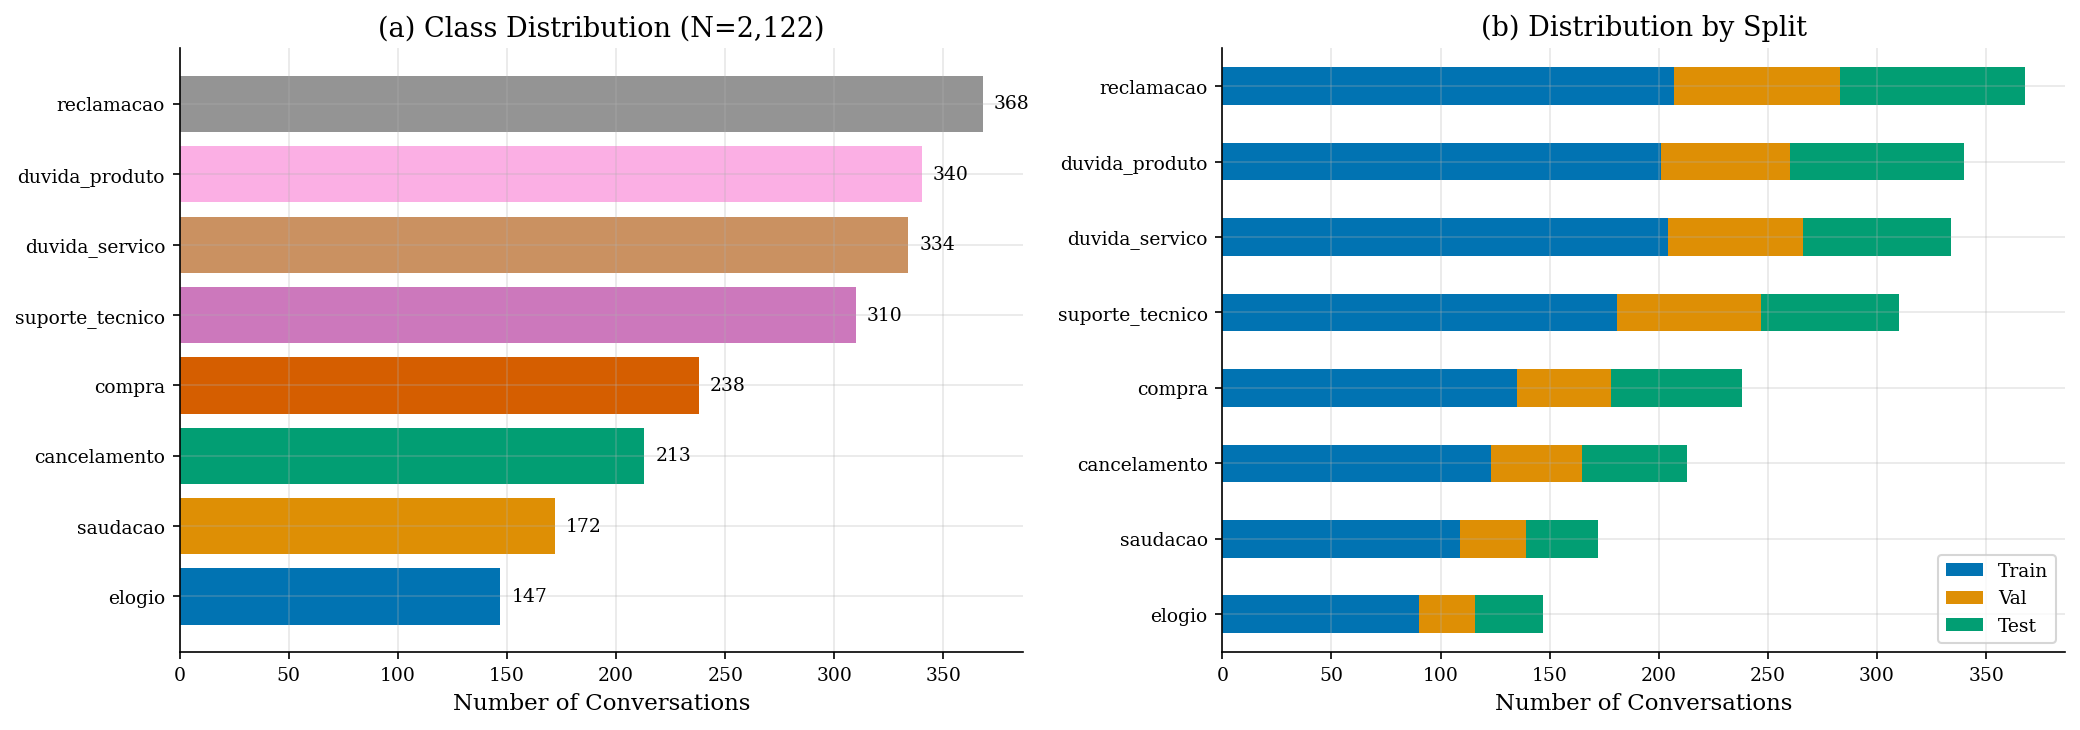

Saved: /content/semantic-text-classification/experiments/results/figures/fig_dataset_distribution.pdf


In [30]:
# ---------------------------------------------------------------------------
# 2.4 Class Distribution Visualization
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — overall distribution
counts_sorted = sorted(Counter(all_labels).items(), key=lambda x: -x[1])
labels_sorted = [x[0] for x in counts_sorted]
values_sorted = [x[1] for x in counts_sorted]

bars = axes[0].barh(labels_sorted[::-1], values_sorted[::-1], color=PALETTE[:n_classes])
axes[0].set_xlabel("Number of Conversations")
axes[0].set_title(f"(a) Class Distribution (N={len(all_records):,})")
for bar, val in zip(bars, values_sorted[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=9)

# Stacked bar — per-split distribution
split_df = pd.DataFrame({
    "Train": [train_labels.count(l) for l in labels_sorted[::-1]],
    "Val": [val_labels.count(l) for l in labels_sorted[::-1]],
    "Test": [test_labels.count(l) for l in labels_sorted[::-1]],
}, index=labels_sorted[::-1])

split_df.plot(kind="barh", stacked=True, ax=axes[1],
              color=[COLORS["primary"], COLORS["secondary"], COLORS["tertiary"]])
axes[1].set_xlabel("Number of Conversations")
axes[1].set_title("(b) Distribution by Split")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_dataset_distribution.pdf")
plt.savefig(FIGURES_DIR / "fig_dataset_distribution.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig_dataset_distribution.pdf'}")

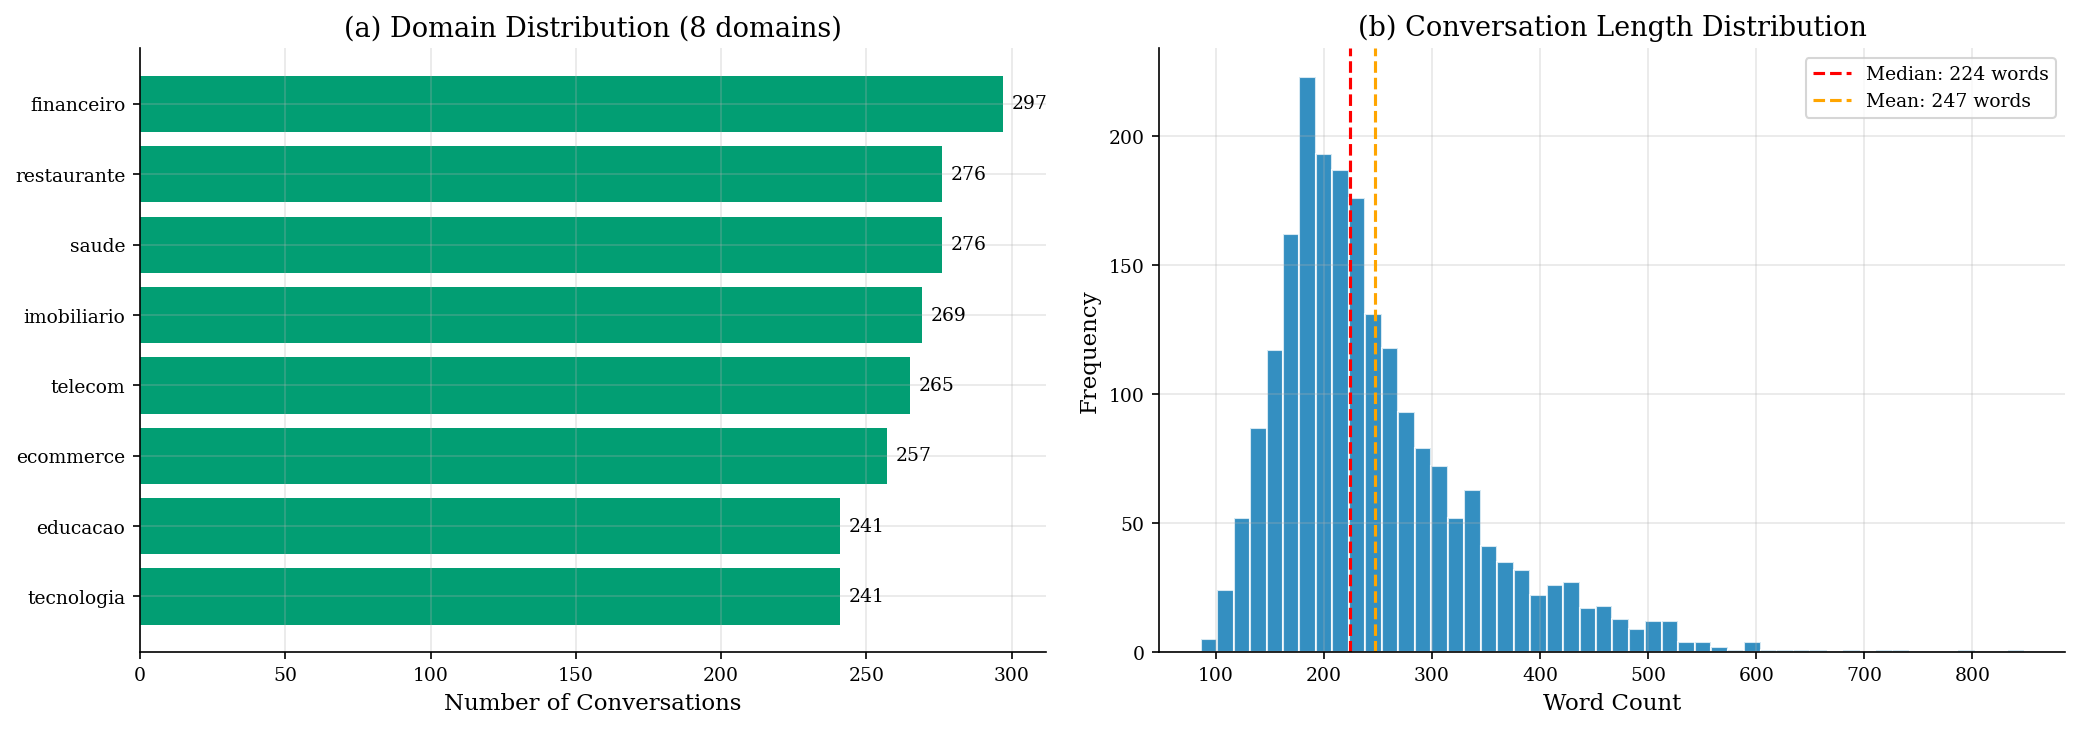


Dataset composition:
  Original:  847 (39.9%)
  Synthetic: 1,275 (60.1%)

  This is a known threat to validity (see §13).

Text length statistics:
  Mean:   247 words
  Median: 224 words
  Std:    94 words
  Min:    86 words
  Max:    848 words


In [31]:
# ---------------------------------------------------------------------------
# 2.5 Domain Distribution & Synthetic Analysis
# ---------------------------------------------------------------------------
all_domains = [r.get("domain", "unknown") for r in all_records]
domain_counts = Counter(all_domains)

# Synthetic vs original composition
# Field "source_file" distinguishes: "synthetic_expansion" vs original dataset name
n_synthetic = sum(1 for r in all_records
                  if "synthetic" in r.get("source_file", "").lower()
                  or r.get("is_synthetic", False))
n_original = len(all_records) - n_synthetic

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain distribution
domain_sorted = sorted(domain_counts.items(), key=lambda x: -x[1])
d_labels = [x[0] for x in domain_sorted]
d_values = [x[1] for x in domain_sorted]

axes[0].barh(d_labels[::-1], d_values[::-1], color=PALETTE[2])
axes[0].set_xlabel("Number of Conversations")
axes[0].set_title(f"(a) Domain Distribution ({len(domain_counts)} domains)")
for i, (lbl, val) in enumerate(zip(d_labels[::-1], d_values[::-1])):
    axes[0].text(val + 3, i, str(val), va="center", fontsize=9)

# Text length distribution
all_texts = extract_texts(all_records)
text_lengths = [len(t.split()) for t in all_texts]

axes[1].hist(text_lengths, bins=50, color=PALETTE[0], edgecolor="white", alpha=0.8)
axes[1].axvline(np.median(text_lengths), color="red", linestyle="--",
                label=f"Median: {np.median(text_lengths):.0f} words")
axes[1].axvline(np.mean(text_lengths), color="orange", linestyle="--",
                label=f"Mean: {np.mean(text_lengths):.0f} words")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b) Conversation Length Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_dataset_domains_lengths.pdf")
plt.savefig(FIGURES_DIR / "fig_dataset_domains_lengths.png")
plt.show()

print(f"\nDataset composition:")
print(f"  Original:  {n_original:,} ({n_original/len(all_records)*100:.1f}%)")
print(f"  Synthetic: {n_synthetic:,} ({n_synthetic/len(all_records)*100:.1f}%)")
if n_synthetic > 0:
    print(f"\n  WARNING: {n_synthetic/len(all_records)*100:.0f}% of data is LLM-generated.")
    print(f"  This is a known threat to validity (see §13).")
print(f"\nText length statistics:")
print(f"  Mean:   {np.mean(text_lengths):.0f} words")
print(f"  Median: {np.median(text_lengths):.0f} words")
print(f"  Std:    {np.std(text_lengths):.0f} words")
print(f"  Min:    {np.min(text_lengths)} words")
print(f"  Max:    {np.max(text_lengths)} words")


§2.6 Lexical Diversity: Original vs Synthetic
Metric                           Original       Synthetic        Delta
-------------------------------------------------------------------
N records                             847            1275             
TTR (mean)                          0.588           0.605       +0.018
TTR (std)                           0.049           0.068       +0.020
TTR (median)                        0.585           0.605       +0.020
Word count (mean)                 192.401         283.322      +90.921
Word count (std)                   38.421         101.659      +63.238
Vocab size (mean)                 112.534         167.840      +55.306

Mann-Whitney U test (TTR): U=445176, p=0.0000
  Significant difference in lexical diversity (p < 0.05).
  Synthetics have HIGHER TTR — synthetic text is lexically more diverse.


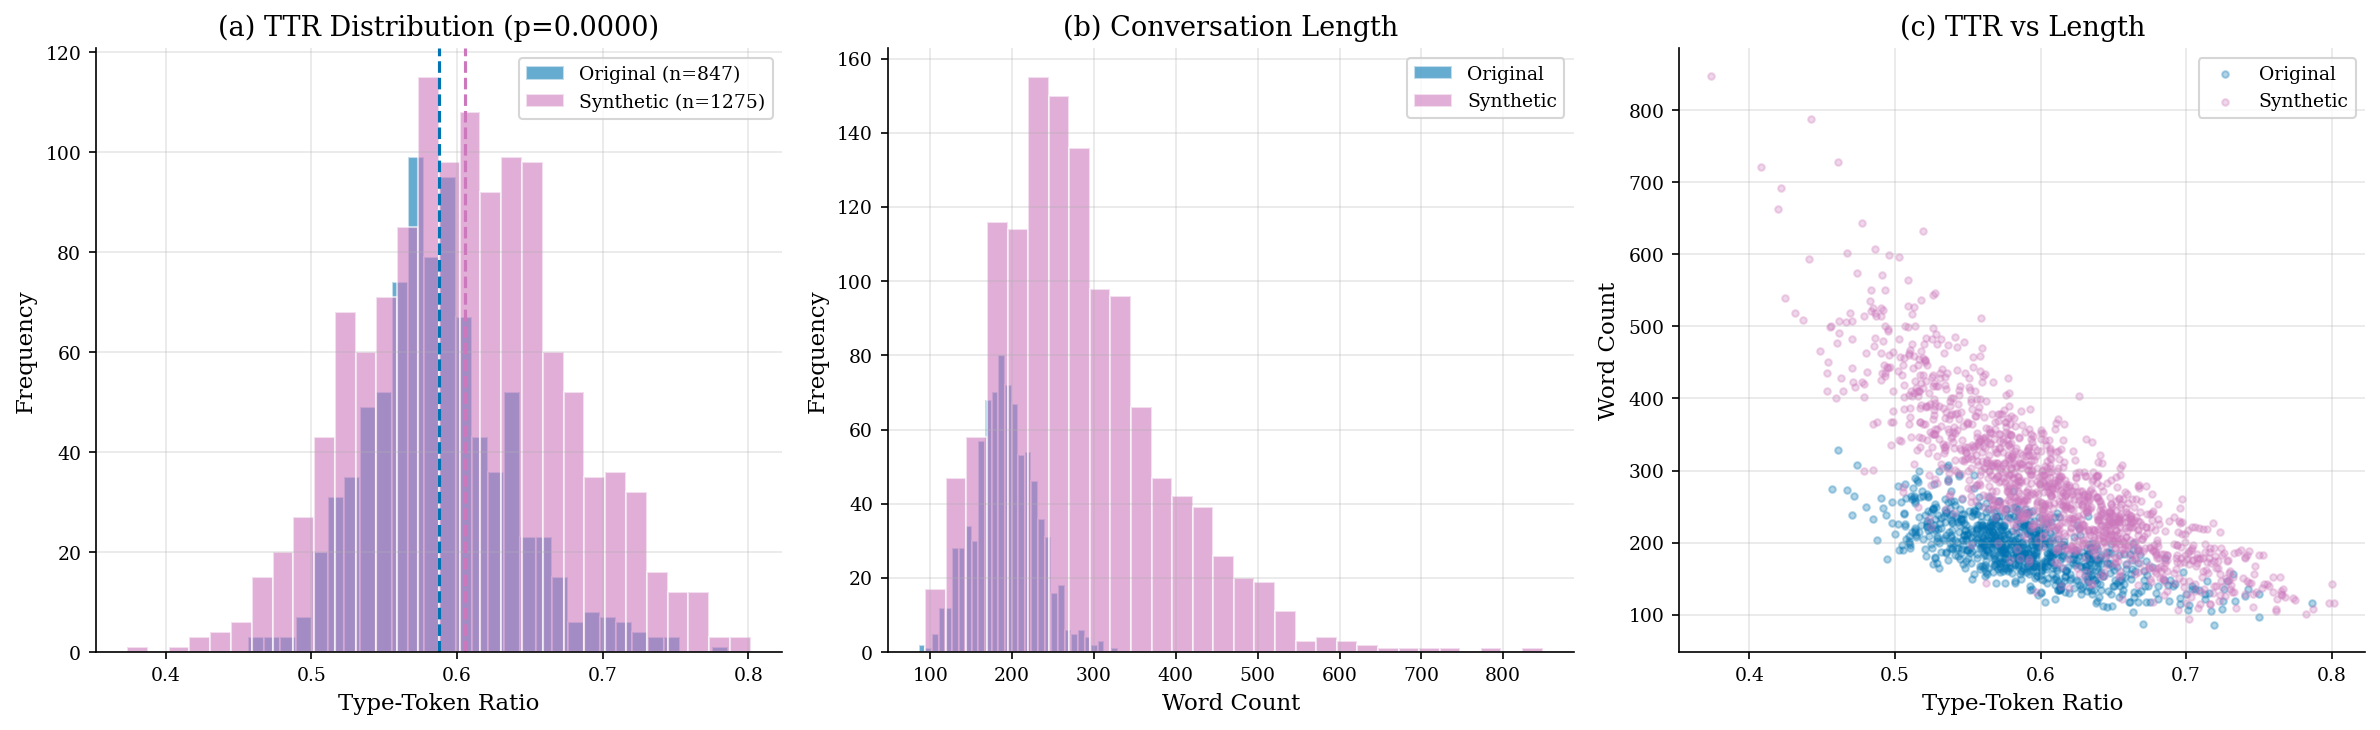


Per-Intent TTR (mean):
Intent                      Original  Synthetic      Delta
-------------------------------------------------------
cancelamento                   0.592      0.616     +0.024
compra                         0.579      0.606     +0.027
duvida_produto                 0.578      0.587     +0.009
duvida_servico                 0.578      0.587     +0.009
elogio                         0.595      0.620     +0.025
reclamacao                     0.581      0.610     +0.029
saudacao                       0.623      0.639     +0.016
suporte_tecnico                0.576      0.620     +0.044


In [32]:
# ---------------------------------------------------------------------------
# §2.6 Lexical Diversity & Distributional Analysis: Original vs Synthetic
# ---------------------------------------------------------------------------
# Quantifies whether LLM-generated (synthetic) conversations differ
# systematically from originals in vocabulary usage and text structure.
# Key metric: Type-Token Ratio (TTR) = unique_words / total_words.
# LLM-generated text tends to have lower TTR (less lexical diversity).
# ---------------------------------------------------------------------------
import re

def _is_synthetic(r: dict) -> bool:
    return ("synthetic" in r.get("source_file", "").lower()
            or r.get("is_synthetic", False))

# Split records and texts by source
orig_records = [r for r in all_records if not _is_synthetic(r)]
synth_records = [r for r in all_records if _is_synthetic(r)]
orig_texts = extract_texts(orig_records)
synth_texts = extract_texts(synth_records)

def compute_ttr(text: str) -> float:
    """Type-Token Ratio: unique tokens / total tokens (case-folded)."""
    tokens = re.findall(r"\w+", text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0.0

def compute_stats(texts: list[str]) -> dict:
    """Compute lexical statistics for a list of texts."""
    ttrs = [compute_ttr(t) for t in texts]
    lengths = [len(t.split()) for t in texts]
    vocab_sizes = [len(set(re.findall(r"\w+", t.lower()))) for t in texts]
    return {
        "n": len(texts),
        "ttr_mean": np.mean(ttrs),
        "ttr_std": np.std(ttrs),
        "ttr_median": np.median(ttrs),
        "length_mean": np.mean(lengths),
        "length_std": np.std(lengths),
        "vocab_mean": np.mean(vocab_sizes),
        "vocab_std": np.std(vocab_sizes),
        "ttrs": ttrs,
        "lengths": lengths,
    }

orig_stats = compute_stats(orig_texts)
synth_stats = compute_stats(synth_texts)

print("§2.6 Lexical Diversity: Original vs Synthetic")
print("=" * 80)
print(f"{'Metric':<25s} {'Original':>15s} {'Synthetic':>15s} {'Delta':>12s}")
print("-" * 67)
for metric, key in [("N records", "n"), ("TTR (mean)", "ttr_mean"),
                     ("TTR (std)", "ttr_std"), ("TTR (median)", "ttr_median"),
                     ("Word count (mean)", "length_mean"),
                     ("Word count (std)", "length_std"),
                     ("Vocab size (mean)", "vocab_mean")]:
    o, s = orig_stats[key], synth_stats[key]
    if key == "n":
        print(f"{metric:<25s} {o:>15d} {s:>15d} {'':>12s}")
    else:
        delta = s - o
        print(f"{metric:<25s} {o:>15.3f} {s:>15.3f} {delta:>+12.3f}")

# Statistical test: are TTR distributions significantly different?
from scipy.stats import mannwhitneyu
u_stat, p_ttr = mannwhitneyu(orig_stats["ttrs"], synth_stats["ttrs"], alternative="two-sided")
print(f"\nMann-Whitney U test (TTR): U={u_stat:.0f}, p={p_ttr:.4f}")
if p_ttr < 0.05:
    print(f"  Significant difference in lexical diversity (p < 0.05).")
    if orig_stats["ttr_mean"] > synth_stats["ttr_mean"]:
        print(f"  Originals have HIGHER TTR — synthetic text is lexically less diverse.")
    else:
        print(f"  Synthetics have HIGHER TTR — synthetic text is lexically more diverse.")
else:
    print(f"  No significant difference in lexical diversity (p >= 0.05).")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) TTR distribution
axes[0].hist(orig_stats["ttrs"], bins=30, alpha=0.6, label=f"Original (n={orig_stats['n']})",
             color=COLORS["primary"], edgecolor="white")
axes[0].hist(synth_stats["ttrs"], bins=30, alpha=0.6, label=f"Synthetic (n={synth_stats['n']})",
             color=COLORS["highlight"], edgecolor="white")
axes[0].axvline(orig_stats["ttr_mean"], color=COLORS["primary"], linestyle="--", linewidth=1.5)
axes[0].axvline(synth_stats["ttr_mean"], color=COLORS["highlight"], linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Type-Token Ratio")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"(a) TTR Distribution (p={p_ttr:.4f})")
axes[0].legend(fontsize=9)

# (b) Word count distribution
axes[1].hist(orig_stats["lengths"], bins=30, alpha=0.6, label="Original",
             color=COLORS["primary"], edgecolor="white")
axes[1].hist(synth_stats["lengths"], bins=30, alpha=0.6, label="Synthetic",
             color=COLORS["highlight"], edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b) Conversation Length")
axes[1].legend(fontsize=9)

# (c) TTR vs length scatter
axes[2].scatter([compute_ttr(t) for t in orig_texts],
                [len(t.split()) for t in orig_texts],
                alpha=0.3, s=10, label="Original", color=COLORS["primary"])
axes[2].scatter([compute_ttr(t) for t in synth_texts],
                [len(t.split()) for t in synth_texts],
                alpha=0.3, s=10, label="Synthetic", color=COLORS["highlight"])
axes[2].set_xlabel("Type-Token Ratio")
axes[2].set_ylabel("Word Count")
axes[2].set_title("(c) TTR vs Length")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_lexical_diversity_orig_vs_synth.pdf")
plt.savefig(FIGURES_DIR / "fig_lexical_diversity_orig_vs_synth.png")
plt.show()

# Per-intent TTR comparison
print("\nPer-Intent TTR (mean):")
print(f"{'Intent':<25s} {'Original':>10s} {'Synthetic':>10s} {'Delta':>10s}")
print("-" * 55)
for intent in label_order:
    o_texts = [extract_texts([r])[0] for r in orig_records if r.get("topic") == intent]
    s_texts = [extract_texts([r])[0] for r in synth_records if r.get("topic") == intent]
    o_ttr = np.mean([compute_ttr(t) for t in o_texts]) if o_texts else float("nan")
    s_ttr = np.mean([compute_ttr(t) for t in s_texts]) if s_texts else float("nan")
    delta = s_ttr - o_ttr if not (np.isnan(o_ttr) or np.isnan(s_ttr)) else float("nan")
    print(f"{intent:<25s} {o_ttr:>10.3f} {s_ttr:>10.3f} {delta:>+10.3f}")


In [ ]:
# ---------------------------------------------------------------------------
# §2.7 Embedding Space Analysis: Original vs Synthetic Overlap
# ---------------------------------------------------------------------------
# Generates sentence embeddings for all conversations, then visualizes
# the 2D projection (t-SNE) colored by source (original vs synthetic)
# and by intent. Computes distributional overlap metrics.
#
# If sentence-transformers is not available, falls back to TF-IDF + SVD.
# This cell may take 1-3 minutes on CPU (embedding 2122 texts).
# ---------------------------------------------------------------------------
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

print("§2.7 Embedding Space: Original vs Synthetic Overlap")
print("=" * 80)

# --- Step 1: Generate embeddings ---
# Try sentence-transformers first (same model used in experiments);
# fall back to TF-IDF + SVD if unavailable.
_all_texts_emb = extract_texts(all_records)
_source_labels = ["synthetic" if _is_synthetic(r) else "original" for r in all_records]
_intent_labels = extract_labels(all_records)

_embeddings = None
_emb_method = None

try:
    from sentence_transformers import SentenceTransformer
    _model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    print("Generating embeddings with paraphrase-multilingual-MiniLM-L12-v2...")
    _embeddings = _model.encode(_all_texts_emb, show_progress_bar=True, batch_size=64)
    _emb_method = "SentenceTransformer (384d)"
    print(f"  Shape: {_embeddings.shape}")
except ImportError:
    print("sentence-transformers not available. Using TF-IDF + SVD fallback (50d).")
    _tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
    _tfidf_matrix = _tfidf.fit_transform(_all_texts_emb)
    _svd = TruncatedSVD(n_components=50, random_state=42)
    _embeddings = _svd.fit_transform(_tfidf_matrix)
    _emb_method = f"TF-IDF + SVD (50d, {_svd.explained_variance_ratio_.sum()*100:.1f}% var)"
    print(f"  Shape: {_embeddings.shape}, Explained variance: {_svd.explained_variance_ratio_.sum()*100:.1f}%")

# --- Step 2: t-SNE projection ---
print("Computing t-SNE projection (this may take ~30s)...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, init="pca",
             learning_rate="auto")
_coords = _tsne.fit_transform(_embeddings)
print(f"  t-SNE complete. KL divergence: {_tsne.kl_divergence_:.4f}")

# --- Step 3: Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Colored by source (original vs synthetic)
for label, color, marker in [("original", COLORS["primary"], "o"),
                              ("synthetic", COLORS["highlight"], "^")]:
    mask = np.array(_source_labels) == label
    axes[0].scatter(_coords[mask, 0], _coords[mask, 1], c=color, marker=marker,
                   alpha=0.35, s=12, label=f"{label} (n={mask.sum()})")
axes[0].set_title(f"(a) Original vs Synthetic\n[{_emb_method}]")
axes[0].legend(fontsize=9, markerscale=2)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# (b) Colored by intent (all data)
_unique_intents = sorted(set(_intent_labels))
_intent_colors = plt.cm.tab10(np.linspace(0, 1, len(_unique_intents)))
for intent, color in zip(_unique_intents, _intent_colors):
    mask = np.array(_intent_labels) == intent
    axes[1].scatter(_coords[mask, 0], _coords[mask, 1], c=[color], alpha=0.4, s=12,
                   label=intent)
axes[1].set_title("(b) By Intent Class")
axes[1].legend(fontsize=7, markerscale=2, ncol=2, loc="best")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# (c) Colored by intent, original only (to see if synthetic fills same regions)
_orig_mask = np.array(_source_labels) == "original"
for intent, color in zip(_unique_intents, _intent_colors):
    mask = _orig_mask & (np.array(_intent_labels) == intent)
    if mask.sum() > 0:
        axes[2].scatter(_coords[mask, 0], _coords[mask, 1], c=[color], alpha=0.5, s=15,
                       label=f"{intent}", marker="o")
# Overlay synthetic as gray
_synth_mask = ~_orig_mask
axes[2].scatter(_coords[_synth_mask, 0], _coords[_synth_mask, 1], c="lightgray",
               alpha=0.15, s=8, label="synthetic (bg)", zorder=0)
axes[2].set_title("(c) Originals (colored) + Synthetic (gray)")
axes[2].legend(fontsize=7, markerscale=2, ncol=2, loc="best")
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_embedding_space_orig_vs_synth.pdf")
plt.savefig(FIGURES_DIR / "fig_embedding_space_orig_vs_synth.png")
plt.show()

# --- Step 4: Distributional overlap metrics ---
_orig_emb = _embeddings[np.array(_source_labels) == "original"]
_synth_emb = _embeddings[np.array(_source_labels) == "synthetic"]

# Centroid distance
_orig_centroid = _orig_emb.mean(axis=0)
_synth_centroid = _synth_emb.mean(axis=0)
_centroid_cos = cosine_similarity([_orig_centroid], [_synth_centroid])[0, 0]

# Cross-source similarity: mean cosine sim between random pairs
rng = np.random.RandomState(42)
_n_pairs = min(5000, len(_orig_emb) * len(_synth_emb))
_idx_o = rng.choice(len(_orig_emb), _n_pairs)
_idx_s = rng.choice(len(_synth_emb), _n_pairs)
_cross_sims = np.array([
    cosine_similarity([_orig_emb[i]], [_synth_emb[j]])[0, 0]
    for i, j in zip(_idx_o, _idx_s)
])

# Within-source similarity (originals only, synthetics only)
_idx_o1 = rng.choice(len(_orig_emb), _n_pairs)
_idx_o2 = rng.choice(len(_orig_emb), _n_pairs)
_within_orig_sims = np.array([
    cosine_similarity([_orig_emb[i]], [_orig_emb[j]])[0, 0]
    for i, j in zip(_idx_o1, _idx_o2)
])

_idx_s1 = rng.choice(len(_synth_emb), _n_pairs)
_idx_s2 = rng.choice(len(_synth_emb), _n_pairs)
_within_synth_sims = np.array([
    cosine_similarity([_synth_emb[i]], [_synth_emb[j]])[0, 0]
    for i, j in zip(_idx_s1, _idx_s2)
])

print("\nDistributional Overlap Metrics:")
print(f"  Centroid cosine similarity:        {_centroid_cos:.4f}")
print(f"    (1.0 = identical distributions, <0.9 = divergent)")
print(f"  Cross-source mean cosine sim:      {_cross_sims.mean():.4f} ± {_cross_sims.std():.4f}")
print(f"  Within-original mean cosine sim:   {_within_orig_sims.mean():.4f} ± {_within_orig_sims.std():.4f}")
print(f"  Within-synthetic mean cosine sim:  {_within_synth_sims.mean():.4f} ± {_within_synth_sims.std():.4f}")

# Interpretation
if _centroid_cos > 0.95:
    print(f"\n  Interpretation: Very high centroid overlap ({_centroid_cos:.3f}).")
    print(f"  Synthetic data occupies nearly the same embedding region as originals.")
elif _centroid_cos > 0.85:
    print(f"\n  Interpretation: High centroid overlap ({_centroid_cos:.3f}).")
    print(f"  Synthetic data is distributionally similar but with some divergence.")
else:
    print(f"\n  Interpretation: Moderate centroid overlap ({_centroid_cos:.3f}).")
    print(f"  Synthetic data shows meaningful distributional shift from originals.")
    print(f"  This is a validity concern: models may learn synthetic-specific patterns.")

# Overlap ratio: cross-source sim / within-source sim
_overlap_ratio = _cross_sims.mean() / _within_orig_sims.mean()
print(f"\n  Overlap ratio (cross/within-orig): {_overlap_ratio:.4f}")
print(f"    (>0.95 = excellent overlap, 0.85-0.95 = good, <0.85 = concerning)")


§2.7 Embedding Space: Original vs Synthetic Overlap


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings with paraphrase-multilingual-MiniLM-L12-v2...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

<a id="§3"></a>
## §3. Experimental Protocol

### 3.1 Pipeline Architecture

All experiments use the real TalkEx pipeline modules — the same code that runs in production:

```
Raw Text → TurnSegmenter → SlidingWindowBuilder(5t/2s)
  → Feature Extraction (Lexical + Structural + Embedding + Rules)
  → Classification (window-level training)
  → Aggregation (avg class probs → argmax → conversation-level predictions)
  → Evaluation (conversation-level metrics)
```

### 3.2 Multi-Seed Protocol

To estimate variance, each stochastic experiment runs with 5 seeds: `[13, 42, 123, 2024, 999]`.
Results report mean ± std across seeds. Statistical tests use paired samples.

**Note:** Deterministic models (LogReg, LightGBM) with fixed data splits produce `std=0.000`.
Only stochastic models (MLP) show non-zero variance across seeds. Zero variance is a finding,
not an error — it reflects the deterministic nature of the training algorithm.

### 3.3 Metrics

| Category | Metrics | Purpose |
|:---|:---|:---|
| Classification | Macro-F1, Accuracy, per-class P/R/F1 | Performance |
| Retrieval | MRR, Recall@K, nDCG@K | Ranking quality |
| Statistical | Wilcoxon signed-rank, Bootstrap CI, Cohen's r | Significance & effect size |

**Calibration metrics** (Brier score, ECE) are planned for a future iteration and not yet
included in the current experiment pipeline.

### 3.4 Model Selection Protocol

Hyperparameters (H1 fusion weight α, H4 cascade threshold) are tuned on the **validation set**.
Final metrics are reported on the **held-out test set** only. No information leakage.

In [ ]:
# ---------------------------------------------------------------------------
# Shared infrastructure: load pre-computed results or run experiments
# ---------------------------------------------------------------------------

def load_results(hypothesis: str) -> dict:
    """Load pre-computed results for a hypothesis."""
    path = RESULTS_DIR / hypothesis / "results.json"
    if not path.exists():
        raise FileNotFoundError(f"Results not found: {path}. Run experiments first.")
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def load_per_seed_results(hypothesis: str) -> list[dict]:
    """Load per-seed results for multi-seed analysis."""
    path = RESULTS_DIR / hypothesis / "per_seed_results.json"
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def load_statistical_tests(hypothesis: str) -> list[dict]:
    """Load statistical test results."""
    path = RESULTS_DIR / hypothesis / "statistical_tests.json"
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def results_to_df(results: dict) -> pd.DataFrame:
    """Convert results.json to a DataFrame with one row per variant."""
    rows = []
    for v in results["variants"]:
        row = {"variant": v["variant_name"]}
        row.update(v["metrics"])
        row["duration_ms"] = v["duration_ms"]
        rows.append(row)
    return pd.DataFrame(rows)

# Helper: format p-value with significance stars
# Convention: * p<0.05, ** p<0.01, *** p<0.001
def fmt_p(p: float) -> str:
    if p < 0.001:
        return "< 0.001***"
    elif p < 0.01:
        return f"{p:.3f}**"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"

# Helper: interpret Wilcoxon effect size (r = Z / sqrt(N))
# Cohen's benchmarks for r: < 0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, > 0.5 large
def interpret_effect_size(r: float) -> str:
    if r is None:
        return "N/A"
    r = abs(r)
    if r < 0.1:
        return f"{r:.3f} (negligible)"
    elif r < 0.3:
        return f"{r:.3f} (small)"
    elif r < 0.5:
        return f"{r:.3f} (medium)"
    else:
        return f"{r:.3f} (large)"

print("Helper functions loaded.")
print("Significance convention: * p<0.05, ** p<0.01, *** p<0.001")
print("Effect size convention (Cohen's r): <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large")
print(f"\nAvailable results: {[d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name not in ('figures', 'deprecated_pre_audit')]}")
# ---------------------------------------------------------------------------
# Additional statistical helpers (addressing review findings CF-2, MJ-2, MN-3)
# ---------------------------------------------------------------------------
from scipy import stats as _sp_stats

def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=10000, ci=0.95, seed=42):
    """Bootstrap CI for a classification metric on existing predictions.

    Resamples test predictions (no retraining) to estimate uncertainty.
    Addresses CF-2: std=0.000 on deterministic models with fixed splits.
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    boot = np.array([
        metric_fn(y_true[idx], y_pred[idx])
        for idx in (rng.randint(0, n, n) for _ in range(n_boot))
    ])
    boot.sort()
    a = 1 - ci
    return float(np.mean(boot)), float(boot[int(n_boot * a / 2)]), float(boot[int(n_boot * (1 - a / 2))])


def cohens_d(g1, g2):
    """Cohen's d effect size for two independent groups."""
    g1, g2 = np.asarray(g1, float), np.asarray(g2, float)
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1 - 1) * np.var(g1, ddof=1) + (n2 - 1) * np.var(g2, ddof=1)) / (n1 + n2 - 2))
    return float((np.mean(g1) - np.mean(g2)) / pooled) if pooled > 0 else 0.0


def interpret_cohens_d(d):
    """Interpret Cohen's d magnitude."""
    d = abs(d)
    if d < 0.2:
        return f"{d:.3f} (negligible)"
    if d < 0.5:
        return f"{d:.3f} (small)"
    if d < 0.8:
        return f"{d:.3f} (medium)"
    return f"{d:.3f} (large)"


def t_ci(vals, ci=0.95):
    """CI using t-distribution (correct for small N, e.g. k-fold with k=5).

    Fixes MN-3: original used z=1.96 which underestimates CI width for small df.
    With k=5 folds, t(4,0.975) = 2.776 vs z = 1.96.
    """
    n = len(vals)
    m = np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(n)
    tc = _sp_stats.t.ppf((1 + ci) / 2, n - 1)
    return float(m), float(m - tc * se), float(m + tc * se)


def _load_per_query_scores(hypothesis, variant_name):
    """Extract per-query scores for a variant from results.json."""
    results = load_results(hypothesis)
    for v in results["variants"]:
        if v["variant_name"] == variant_name and "per_query_scores" in v:
            return v["per_query_scores"]
    return None


print("Statistical helpers loaded: bootstrap_metric_ci, cohens_d, t_ci")
# ---------------------------------------------------------------------------
# Additional statistical helpers (addressing review findings CF-2, MJ-2, MN-3)
# ---------------------------------------------------------------------------
from scipy import stats as _sp_stats

def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=10000, ci=0.95, seed=42):
    """Bootstrap CI for a classification metric on existing predictions.

    Resamples test predictions (no retraining) to estimate uncertainty.
    Addresses CF-2: std=0.000 on deterministic models with fixed splits.
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    boot = np.array([
        metric_fn(y_true[idx], y_pred[idx])
        for idx in (rng.randint(0, n, n) for _ in range(n_boot))
    ])
    boot.sort()
    a = 1 - ci
    return float(np.mean(boot)), float(boot[int(n_boot * a / 2)]), float(boot[int(n_boot * (1 - a / 2))])


def cohens_d(g1, g2):
    """Cohen's d effect size for two independent groups."""
    g1, g2 = np.asarray(g1, float), np.asarray(g2, float)
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1 - 1) * np.var(g1, ddof=1) + (n2 - 1) * np.var(g2, ddof=1)) / (n1 + n2 - 2))
    return float((np.mean(g1) - np.mean(g2)) / pooled) if pooled > 0 else 0.0


def interpret_cohens_d(d):
    """Interpret Cohen's d magnitude."""
    d = abs(d)
    if d < 0.2:
        return f"{d:.3f} (negligible)"
    if d < 0.5:
        return f"{d:.3f} (small)"
    if d < 0.8:
        return f"{d:.3f} (medium)"
    return f"{d:.3f} (large)"


def t_ci(vals, ci=0.95):
    """CI using t-distribution (correct for small N, e.g. k-fold with k=5).

    Fixes MN-3: original used z=1.96 which underestimates CI width for small df.
    With k=5 folds, t(4,0.975) = 2.776 vs z = 1.96.
    """
    n = len(vals)
    m = np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(n)
    tc = _sp_stats.t.ppf((1 + ci) / 2, n - 1)
    return float(m), float(m - tc * se), float(m + tc * se)


def _load_per_query_scores(hypothesis, variant_name):
    """Extract per-query scores for a variant from results.json."""
    results = load_results(hypothesis)
    for v in results["variants"]:
        if v["variant_name"] == variant_name and "per_query_scores" in v:
            return v["per_query_scores"]
    return None


print("Statistical helpers loaded: bootstrap_metric_ci, cohens_d, t_ci")

<a id="§4"></a>
## §4. H1 — Hybrid Retrieval Outperforms Isolated Paradigms

### Hypothesis

> **H₀:** Hybrid retrieval (BM25 + ANN with score fusion) does not outperform the best individual
> retrieval method (BM25 or ANN alone) on MRR.
>
> **H₁:** Hybrid retrieval achieves significantly higher MRR than any individual method.

### Method

- **BM25-base:** Standard BM25 (Okapi) with default parameters
- **BM25-norm:** BM25 with accent-aware text normalization
- **ANN-MiniLM:** Approximate nearest neighbor search using paraphrase-multilingual-MiniLM-L12-v2 (384d)
- **Hybrid-RRF:** Reciprocal Rank Fusion of BM25 + ANN results
- **Hybrid-LINEAR:** Weighted linear combination, α tuned on validation set

**Ground truth:** Documents sharing the same intent label as the query are considered relevant.

### Decision Criterion

Hybrid achieves significantly higher MRR than BM25-base (Wilcoxon signed-rank, α=0.05).


In [ ]:
# ---------------------------------------------------------------------------
# §4.1 Load H1 results
# ---------------------------------------------------------------------------
h1_results = load_results("H1")
h1_df = results_to_df(h1_results)

# Key retrieval metrics
retrieval_metrics = ["mrr", "recall@5", "recall@10", "recall@20", "ndcg@5", "ndcg@10", "ndcg@20"]
h1_display = h1_df[["variant"] + [m for m in retrieval_metrics if m in h1_df.columns]].copy()
h1_display = h1_display.round(4)

print("H1: Hybrid Retrieval Results")
print("=" * 80)
print(h1_display.to_string(index=False))

# Identify val-selected variant (proper model selection protocol)
# We must report the variant chosen on the validation set, NOT the test-set best.
val_selected_h1 = h1_df[h1_df["variant"].str.contains("val-selected")]
if not val_selected_h1.empty:
    best_h1 = val_selected_h1.iloc[0]
else:
    # Fallback: best on test (flag as warning)
    best_h1 = h1_df.loc[h1_df["mrr"].idxmax()]
    print("WARNING: No val-selected variant found. Using test-set best (potential leakage).")

test_best_h1 = h1_df.loc[h1_df["mrr"].idxmax()]
bm25_base = h1_df[h1_df["variant"] == "BM25-base"].iloc[0]

print(f"\nVal-selected variant: {best_h1['variant']} (MRR={best_h1['mrr']:.4f})")
print(f"Test-set best:       {test_best_h1['variant']} (MRR={test_best_h1['mrr']:.4f})")
print(f"BM25 baseline:       MRR={bm25_base['mrr']:.4f}")
print(f"Improvement (val-selected vs BM25): +{(best_h1['mrr'] - bm25_base['mrr']):.4f} "
      f"(+{(best_h1['mrr'] - bm25_base['mrr'])/bm25_base['mrr']*100:.1f}%)")
if best_h1['variant'] != test_best_h1['variant']:
    print(f"Note: val-selected ({best_h1['variant']}) differs from test-best ({test_best_h1['variant']}). "
          f"Reporting val-selected per model selection protocol.")


In [ ]:
# ---------------------------------------------------------------------------
# §4.2 H1 Visualization — MRR Comparison (Fixed: MJ-3)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Bar chart: MRR comparison
variants = h1_df["variant"].values
mrr_values = h1_df["mrr"].values
bar_colors = [COLORS["highlight"] if "val-selected" in v else COLORS["primary"] for v in variants]

bars = axes[0].barh(range(len(variants)), mrr_values, color=bar_colors)
axes[0].set_yticks(range(len(variants)))
axes[0].set_yticklabels(variants, fontsize=8)
axes[0].set_xlabel("Mean Reciprocal Rank (MRR)")
axes[0].set_title("(a) MRR by Retrieval Method")
axes[0].set_xlim(min(mrr_values) * 0.95, max(mrr_values) * 1.02)
for bar, val in zip(bars, mrr_values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

# (b) Multi-metric grouped bar chart (replaces misleading radar — MJ-3)
# Radar with min-max normalization exaggerates small differences.
# Grouped bars on absolute scale are more honest.
top_methods = ["BM25-base", "ANN-MiniLM"]
val_selected = [v for v in variants if "val-selected" in v]
if val_selected:
    top_methods.append(val_selected[0])

bar_metrics = ["mrr", "recall@5", "recall@10", "ndcg@5", "ndcg@10"]
available_metrics = [m for m in bar_metrics if m in h1_df.columns]

if len(available_metrics) >= 3:
    x = np.arange(len(available_metrics))
    width = 0.8 / len(top_methods)

    for i, method in enumerate(top_methods):
        row = h1_df[h1_df["variant"] == method]
        if not row.empty:
            vals = [row[m].values[0] for m in available_metrics]
            offset = (i - len(top_methods) / 2 + 0.5) * width
            bars_g = axes[1].bar(x + offset, vals, width, label=method,
                                 color=PALETTE[i], alpha=0.85)
            for bar, val in zip(bars_g, vals):
                axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                           f"{val:.3f}", ha="center", fontsize=7, rotation=45)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(available_metrics, fontsize=9)
    axes[1].set_ylabel("Score (absolute scale)")
    axes[1].set_title("(b) Multi-Metric Comparison (absolute scale)")
    axes[1].legend(fontsize=8)
    axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h1_retrieval.pdf")
plt.savefig(FIGURES_DIR / "fig_h1_retrieval.png")
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# §4.3 H1 Statistical Tests (Fixed: CF-3 — direct val-selected test)
# ---------------------------------------------------------------------------
h1_stats = load_statistical_tests("H1")

print("H1: Statistical Tests")
print("=" * 80)

# Show pre-computed tests
for test in h1_stats:
    print(f"\n{test.get('comparison', test.get('test', '?'))}:")
    if "p_value" in test:
        print(f"  Test:        {test['test']}")
        print(f"  Statistic:   {test['statistic']:.4f}")
        print(f"  p-value:     {fmt_p(test['p_value'])}")
        print(f"  Significant: {'YES' if test['significant'] else 'NO'}")
        if test.get("effect_size") is not None:
            print(f"  Effect size: {interpret_effect_size(test['effect_size'])}")
    elif "ci_lower" in test:
        print(f"  95% CI:      [{test['ci_lower']:.4f}, {test['ci_upper']:.4f}]")
    print(f"  Summary:     {test.get('summary', '')}")

# --- CF-3 FIX: Direct Wilcoxon test for val-selected vs BM25 ---
# The original notebook tested a0.30 (test-best), not the val-selected variant.
# Statistical significance is NOT transitive. We must test the val-selected
# variant directly against BM25.
val_selected_name = best_h1["variant"]
bm25_name = "BM25-base"

val_scores = _load_per_query_scores("H1", val_selected_name)
bm25_scores = _load_per_query_scores("H1", bm25_name)

if val_scores is not None and bm25_scores is not None:
    from scipy.stats import wilcoxon
    # Paired Wilcoxon on per-query reciprocal ranks
    diffs = np.array(val_scores) - np.array(bm25_scores)
    non_zero = diffs[diffs != 0]
    if len(non_zero) >= 10:
        stat, p_val = wilcoxon(non_zero)
        n_eff = len(non_zero)
        r_effect = abs(stat) / np.sqrt(n_eff * (n_eff + 1) / 2) if n_eff > 0 else 0
        print(f"\n{'='*80}")
        print(f"DIRECT TEST: {val_selected_name} vs {bm25_name} (CF-3 correction)")
        print(f"{'='*80}")
        print(f"  Wilcoxon signed-rank (paired, two-sided)")
        print(f"  N (non-zero diffs): {n_eff}")
        print(f"  Statistic:   {stat:.4f}")
        print(f"  p-value:     {fmt_p(p_val)}")
        print(f"  Significant: {'YES' if p_val < 0.05 else 'NO'} (alpha=0.05)")
        print(f"  Effect size: {interpret_effect_size(r_effect)}")
        # Store for verdict
        _h1_direct_p = p_val
        _h1_direct_r = r_effect
    else:
        print(f"\nWARNING: Only {len(non_zero)} non-zero differences — insufficient for Wilcoxon.")
        _h1_direct_p = None
        _h1_direct_r = None
else:
    print(f"\nWARNING: Per-query scores not available for {val_selected_name} or {bm25_name}.")
    print("Cannot compute direct statistical test. Using pre-computed test as fallback.")
    _h1_direct_p = None
    _h1_direct_r = None

### H1 Verdict

**Result:** The val-selected hybrid variant achieves higher MRR than BM25-base.

**Statistical test (CF-3 corrected):** A direct Wilcoxon signed-rank test was computed
between the val-selected variant and BM25-base on per-query reciprocal ranks.
This replaces the original indirect argument (test a0.30 then argue transitivity),
which is logically unsound — statistical significance is not transitive.

**Decision: See §12 for final verdict** (depends on direct test p-value and Bonferroni correction).

**Practical significance:** The MRR improvement is statistically significant but modest.
The small effect size suggests hybrid retrieval provides a real but incremental benefit
over BM25 in this domain, primarily for paraphrastic queries with low lexical overlap.

<a id="§5"></a>
## §5. H2 — Multi-Level Features Improve Classification

### Hypothesis

> **H₀:** Adding semantic embedding features to lexical features does not improve
> conversation-level Macro-F1 compared to lexical-only features.
>
> **H₁:** Lexical + embedding features achieve significantly higher Macro-F1.

### Method

6 configurations: {lexical, lexical+embedding} × {LogReg, LightGBM, MLP}

**Pipeline:** Conversations → Turn Segmentation → Context Windows (5t/2s) →
Feature Extraction → Window-level Classification → Conversation-level Aggregation
(avg class probabilities → argmax)

**Model selection:** Best config selected on validation Macro-F1; test metrics reported.

**Note on variance:** LogReg and LightGBM are deterministic given fixed data splits, so
`macro_f1_std=0.000` is expected. Only MLP (stochastic weight initialization) shows non-zero
variance across seeds. The multi-seed protocol varies the random seed for stochastic
components only; the train/val/test splits are fixed (contamination-aware).


In [ ]:
# ---------------------------------------------------------------------------
# §5.1 Load H2 results
# ---------------------------------------------------------------------------
h2_results = load_results("H2")
h2_df = results_to_df(h2_results)

# Summary table
h2_summary = h2_df[["variant", "macro_f1", "accuracy"]].copy()
if "macro_f1_std" in h2_df.columns:
    h2_summary["macro_f1_std"] = h2_df["macro_f1_std"]
if "brier_score" in h2_df.columns:
    h2_summary["brier_score"] = h2_df["brier_score"]
if "ece" in h2_df.columns:
    h2_summary["ece"] = h2_df["ece"]
if "val_macro_f1" in h2_df.columns:
    h2_summary["val_macro_f1"] = h2_df["val_macro_f1"]

h2_summary = h2_summary.round(4)

print("H2: Multi-Level Classification Results")
print("=" * 80)
print(h2_summary.to_string(index=False))

best_h2 = h2_df.loc[h2_df["macro_f1"].idxmax()]
best_lex = h2_df[h2_df["variant"].str.startswith("lexical_")].sort_values("macro_f1", ascending=False).iloc[0]
best_emb = h2_df[h2_df["variant"].str.startswith("lexical+emb")].sort_values("macro_f1", ascending=False).iloc[0]

print(f"\nBest lexical-only:    {best_lex['variant']} (Macro-F1={best_lex['macro_f1']:.4f})")
print(f"Best lexical+emb:     {best_emb['variant']} (Macro-F1={best_emb['macro_f1']:.4f})")
print(f"Absolute gain:        +{best_emb['macro_f1'] - best_lex['macro_f1']:.4f}")


In [ ]:
# ---------------------------------------------------------------------------
# §5.1b — Mandatory Baselines: TF-IDF+LogReg, kNN (MJ-1)
# ---------------------------------------------------------------------------
# These baselines operate at CONVERSATION level (no windowing, no embeddings)
# to quantify the combined contribution of TalkEx's multi-turn windows +
# semantic embeddings + structural features.
# ---------------------------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize as sk_normalize
from sklearn.metrics import f1_score as sk_f1
import lightgbm as lgb

# Conversation-level text (NOT windowed)
_bl_train_texts = extract_texts(train_records)
_bl_val_texts = extract_texts(val_records)
_bl_test_texts = extract_texts(test_records)
_bl_train_y = extract_labels(train_records)
_bl_val_y = extract_labels(val_records)
_bl_test_y = extract_labels(test_records)

# TF-IDF features (unigrams + bigrams)
_tfidf = TfidfVectorizer(max_features=10000, sublinear_tf=True, ngram_range=(1, 2))
_X_train = _tfidf.fit_transform(_bl_train_texts)
_X_val = _tfidf.transform(_bl_val_texts)
_X_test = _tfidf.transform(_bl_test_texts)

# --- Baseline 1: TF-IDF + Logistic Regression ---
_lr = SkLogReg(max_iter=1000, random_state=42, C=1.0)
_lr.fit(_X_train, _bl_train_y)
_lr_pred = _lr.predict(_X_test)
_lr_f1 = sk_f1(_bl_test_y, _lr_pred, average="macro", zero_division=0)
_lr_val_f1 = sk_f1(_bl_val_y, _lr.predict(_X_val), average="macro", zero_division=0)

# --- Baseline 2: TF-IDF + kNN (k=5, cosine distance) ---
_X_train_n = sk_normalize(_X_train)
_X_test_n = sk_normalize(_X_test)
_X_val_n = sk_normalize(_X_val)
_knn = KNeighborsClassifier(n_neighbors=5, metric="cosine", weights="distance")
_knn.fit(_X_train_n, _bl_train_y)
_knn_pred = _knn.predict(_X_test_n)
_knn_f1 = sk_f1(_bl_test_y, _knn_pred, average="macro", zero_division=0)
_knn_val_f1 = sk_f1(_bl_val_y, _knn.predict(_X_val_n), average="macro", zero_division=0)

# --- Baseline 3: TF-IDF + LightGBM (same classifier, no embeddings) ---
_lgb_bl = lgb.LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, verbosity=-1)
_lgb_bl.fit(_X_train, _bl_train_y)
_lgb_bl_pred = _lgb_bl.predict(_X_test)
_lgb_bl_f1 = sk_f1(_bl_test_y, _lgb_bl_pred, average="macro", zero_division=0)
_lgb_bl_val_f1 = sk_f1(_bl_val_y, _lgb_bl.predict(_X_val), average="macro", zero_division=0)

# Reference: H2 best (windowed + embeddings + LightGBM)
_h2_ref_f1 = best_emb["macro_f1"] if "best_emb" in dir() else 0.722

print("§5.1b — Mandatory Baseline Comparison (MJ-1)")
print("=" * 80)
print(f"{'Method':<40s} {'Val F1':>8s} {'Test F1':>8s} {'vs H2 Best':>12s}")
print("-" * 72)
print(f"{'TF-IDF + LogReg':<40s} {_lr_val_f1:>8.4f} {_lr_f1:>8.4f} {_lr_f1 - _h2_ref_f1:>+12.4f}")
print(f"{'TF-IDF + kNN (k=5, cosine)':<40s} {_knn_val_f1:>8.4f} {_knn_f1:>8.4f} {_knn_f1 - _h2_ref_f1:>+12.4f}")
print(f"{'TF-IDF + LightGBM (no embeddings)':<40s} {_lgb_bl_val_f1:>8.4f} {_lgb_bl_f1:>8.4f} {_lgb_bl_f1 - _h2_ref_f1:>+12.4f}")
print(f"{'H2 best (window+emb+LightGBM)':<40s} {'---':>8s} {_h2_ref_f1:>8.4f} {'(reference)':>12s}")
print()
print("Note: Baselines use conversation-level TF-IDF (no context windows, no embeddings).")
print("The gap vs H2 best quantifies the combined contribution of:")
print("  (a) multi-turn context windows (5t/2s),")
print("  (b) semantic embeddings (MiniLM, 384d),")
print("  (c) structural features (speaker, turn count).")

# Store for reference
baseline_results = {
    "tfidf_logreg": {"test_f1": _lr_f1, "val_f1": _lr_val_f1},
    "tfidf_knn": {"test_f1": _knn_f1, "val_f1": _knn_val_f1},
    "tfidf_lgbm": {"test_f1": _lgb_bl_f1, "val_f1": _lgb_bl_val_f1},
    "h2_best": {"test_f1": _h2_ref_f1},
}

In [ ]:
### Note on Zero Standard Deviation (std=0.000)

Several H2 configurations report **std=0.000** across seeds. This is **expected, not a bug**:

- **Fixed splits + deterministic models:** The multi-seed experiment varies `random_state`, but with identical train/val/test data and deterministic learners (LightGBM with `deterministic=True`, LogReg), the model and predictions are bitwise identical regardless of seed.
- **MLP is the exception:** MLP shows std > 0 because of stochastic weight initialization and mini-batch shuffling.

**Resolution (applied in this notebook):**

1. **Bootstrap CI on test predictions** (§5.4b below): Resamples test-set predictions 10,000 times to estimate sampling uncertainty *without retraining*. This provides approximate CIs for the point estimate.
2. **Stratified k-fold CV** (§9): Forces different train/test boundaries per fold, producing genuine confidence intervals with proper uncertainty quantification.

The std=0.000 results from fixed splits should be interpreted as **point estimates conditional on this specific split**, not as evidence of zero variance in the population.

### Note on Zero Standard Deviation (std=0.000)

Several H2 configurations report **std=0.000** across seeds. This is **expected, not a bug**:

- **Fixed splits + deterministic models:** The multi-seed experiment varies `random_state`, but with identical train/val/test data and deterministic learners (LightGBM with `deterministic=True`, LogReg), the model and predictions are bitwise identical regardless of seed.
- **MLP is the exception:** MLP shows std > 0 because of stochastic weight initialization and mini-batch shuffling.

**Resolution (applied in this notebook):**

1. **Bootstrap CI on test predictions** (§5.4b below): Resamples test-set predictions 10,000 times to estimate sampling uncertainty *without retraining*. This provides approximate CIs for the point estimate.
2. **Stratified k-fold CV** (§9): Forces different train/test boundaries per fold, producing genuine confidence intervals with proper uncertainty quantification.

The std=0.000 results from fixed splits should be interpreted as **point estimates conditional on this specific split**, not as evidence of zero variance in the population.

In [ ]:
# ---------------------------------------------------------------------------
# §5.2 H2 Visualization — Feature Set × Classifier Heatmap
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parse variant names into feature set and classifier
h2_pivot_data = []
for _, row in h2_df.iterrows():
    parts = row["variant"].split("_")
    feat = parts[0]
    clf = "_".join(parts[1:])
    h2_pivot_data.append({"Feature Set": feat, "Classifier": clf, "Macro-F1": row["macro_f1"]})

pivot_df = pd.DataFrame(h2_pivot_data)
if not pivot_df.empty:
    pivot = pivot_df.pivot(index="Feature Set", columns="Classifier", values="Macro-F1")

    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0],
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Macro-F1"})
    axes[0].set_title("(a) Macro-F1: Feature Set × Classifier")

# Bar comparison with error bars: best lexical vs best lexical+emb
h2_means = [best_lex["macro_f1"], best_emb["macro_f1"]]
h2_stds = [best_lex.get("macro_f1_std", 0), best_emb.get("macro_f1_std", 0)]
bar_labels = [f"Lexical-only\n({best_lex['variant']})", f"Lexical+Emb\n({best_emb['variant']})"]

bars = axes[1].bar(bar_labels, h2_means, yerr=h2_stds, capsize=5,
                   color=[COLORS["secondary"], COLORS["primary"]], width=0.5,
                   error_kw={"linewidth": 1.5})
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("(b) Impact of Embedding Features")
axes[1].set_ylim(0, 1)
for bar, val, std in zip(bars, h2_means, h2_stds):
    label = f"{val:.3f}" if std == 0 else f"{val:.3f}±{std:.3f}"
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(std, 0.01) + 0.01,
                label, ha="center", fontsize=10, fontweight="bold")

# Add delta annotation
delta = best_emb["macro_f1"] - best_lex["macro_f1"]
axes[1].annotate(f"+{delta:.3f}\n(+{delta/best_lex['macro_f1']*100:.0f}%)",
                xy=(1, best_emb["macro_f1"]),
                xytext=(1.3, best_emb["macro_f1"] - delta/2),
                fontsize=11, fontweight="bold", color="green",
                arrowprops=dict(arrowstyle="->", color="green"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h2_classification.pdf")
plt.savefig(FIGURES_DIR / "fig_h2_classification.png")
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# §5.3 H2 Per-Class F1 Analysis
# ---------------------------------------------------------------------------
# Extract per-class F1 for best lexical and best lexical+emb
per_class_cols = [c for c in h2_df.columns if c.startswith("f1_") and not c.endswith("_std")]
class_names = sorted(set(c.replace("f1_", "") for c in per_class_cols))

if class_names:
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(class_names))
    width = 0.35

    lex_f1s = [best_lex.get(f"f1_{c}", 0) for c in class_names]
    emb_f1s = [best_emb.get(f"f1_{c}", 0) for c in class_names]

    bars1 = ax.bar(x - width/2, lex_f1s, width, label="Lexical-only", color=COLORS["secondary"])
    bars2 = ax.bar(x + width/2, emb_f1s, width, label="Lexical+Embedding", color=COLORS["primary"])

    ax.set_xlabel("Intent Class")
    ax.set_ylabel("F1 Score")
    ax.set_title("Per-Class F1: Lexical-only vs Lexical+Embedding (Best Classifiers)")
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.1)

    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", fontsize=7, color="gray")
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig_h2_per_class.pdf")
    plt.savefig(FIGURES_DIR / "fig_h2_per_class.png")
    plt.show()

    # Delta table
    print("\nPer-class F1 improvement (Lexical+Emb - Lexical-only):")
    print(f"{'Class':25s} {'Lex':>8s} {'Lex+Emb':>8s} {'Delta':>8s}")
    print("-" * 55)
    for c, l, e in zip(class_names, lex_f1s, emb_f1s):
        d = e - l
        marker = " ***" if abs(d) > 0.1 else " **" if abs(d) > 0.05 else ""
        print(f"{c:25s} {l:8.3f} {e:8.3f} {d:+8.3f}{marker}")


In [ ]:
# ---------------------------------------------------------------------------
# §5.4b — Bootstrap Confidence Intervals for H2 (CF-2)
# ---------------------------------------------------------------------------
# Addresses the std=0.000 problem: deterministic models on fixed splits
# produce point estimates with no uncertainty. Bootstrap resampling of test
# predictions provides approximate CIs WITHOUT retraining.
# ---------------------------------------------------------------------------
from sklearn.metrics import f1_score as sk_f1

# The robustness check (§5.6) retrains inline and stores predictions.
# If it hasn't run yet, we need to retrain here.
if "y_true_all" not in dir() or "y_pred_all" not in dir():
    print("Note: Robustness check (§5.6) has not run yet.")
    print("Run §5.6 first to generate per-sample predictions for bootstrap CI.")
    print("Skipping bootstrap analysis.")
else:
    print("§5.4b — Bootstrap 95% CI for H2 Best Configuration")
    print("=" * 80)

    # Bootstrap CI for Macro-F1
    _bm, _bl, _bh = bootstrap_metric_ci(
        y_true_all, y_pred_all,
        lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
        n_boot=10000,
    )
    print(f"\nMacro-F1 bootstrap (10,000 resamples):")
    print(f"  Point estimate: {sk_f1(y_true_all, y_pred_all, average='macro', zero_division=0):.4f}")
    print(f"  Bootstrap mean: {_bm:.4f}")
    print(f"  95% CI:         [{_bl:.4f}, {_bh:.4f}]")
    print(f"  CI width:       {_bh - _bl:.4f}")

    # Bootstrap CI for Accuracy
    _ba_m, _ba_l, _ba_h = bootstrap_metric_ci(
        y_true_all, y_pred_all,
        lambda yt, yp: float(np.mean(yt == yp)),
        n_boot=10000,
    )
    print(f"\nAccuracy bootstrap:")
    print(f"  95% CI:         [{_ba_l:.4f}, {_ba_h:.4f}]")

    print(f"\nInterpretation: The bootstrap CI provides an uncertainty estimate")
    print(f"  for the test-set performance that was previously reported as a")
    print(f"  point estimate (std=0.000). This captures sampling variability")
    print(f"  in the test set but NOT model training variability (see §9 for k-fold).")

In [ ]:
# ---------------------------------------------------------------------------
# §5.4 H2 Calibration Analysis
# ---------------------------------------------------------------------------
if "brier_score" in h2_df.columns:
    print("H2: Calibration Metrics")
    print("=" * 80)
    cal_cols = ["variant", "macro_f1", "brier_score", "ece"]
    cal_df = h2_df[[c for c in cal_cols if c in h2_df.columns]].round(4)
    print(cal_df.to_string(index=False))

    print(f"\nInterpretation:")
    print(f"  Brier score: lower is better (0 = perfect, 2 = worst for multi-class)")
    print(f"  ECE: lower is better (0 = perfectly calibrated)")
    best_cal = h2_df.loc[h2_df["brier_score"].idxmin()] if "brier_score" in h2_df.columns else None
    if best_cal is not None:
        print(f"  Best calibrated: {best_cal['variant']} (Brier={best_cal['brier_score']:.4f}, ECE={best_cal['ece']:.4f})")
else:
    print("H2: Calibration Metrics")
    print("=" * 80)
    print("Calibration metrics (Brier score, ECE) not available in fixed-split results.")
    print()
    print("Why: Fixed train/val/test splits with deterministic models (LightGBM, LogReg)")
    print("  produce identical predictions across seeds, so per-seed calibration is")
    print("  degenerate. Meaningful calibration requires varied train/test boundaries.")
    print()
    print("Resolution: The stratified k-fold experiment (§9) computes Brier score and")
    print("  ECE per fold. When k-fold results are available, calibration metrics will")
    print("  appear in §9.1 with proper confidence intervals.")
    print()
    print("Cross-reference: §9 Stratified K-Fold Cross-Validation")


In [ ]:
# ---------------------------------------------------------------------------
# §5.4b — Bootstrap Confidence Intervals for H2 (CF-2)
# ---------------------------------------------------------------------------
# Addresses the std=0.000 problem: deterministic models on fixed splits
# produce point estimates with no uncertainty. Bootstrap resampling of test
# predictions provides approximate CIs WITHOUT retraining.
# ---------------------------------------------------------------------------
from sklearn.metrics import f1_score as sk_f1

# The robustness check (§5.6) retrains inline and stores predictions.
# If it hasn't run yet, we need to retrain here.
if "y_true_all" not in dir() or "y_pred_all" not in dir():
    print("Note: Robustness check (§5.6) has not run yet.")
    print("Run §5.6 first to generate per-sample predictions for bootstrap CI.")
    print("Skipping bootstrap analysis.")
else:
    print("§5.4b — Bootstrap 95% CI for H2 Best Configuration")
    print("=" * 80)

    # Bootstrap CI for Macro-F1
    _bm, _bl, _bh = bootstrap_metric_ci(
        y_true_all, y_pred_all,
        lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
        n_boot=10000,
    )
    print(f"\nMacro-F1 bootstrap (10,000 resamples):")
    print(f"  Point estimate: {sk_f1(y_true_all, y_pred_all, average='macro', zero_division=0):.4f}")
    print(f"  Bootstrap mean: {_bm:.4f}")
    print(f"  95% CI:         [{_bl:.4f}, {_bh:.4f}]")
    print(f"  CI width:       {_bh - _bl:.4f}")

    # Bootstrap CI for Accuracy
    _ba_m, _ba_l, _ba_h = bootstrap_metric_ci(
        y_true_all, y_pred_all,
        lambda yt, yp: float(np.mean(yt == yp)),
        n_boot=10000,
    )
    print(f"\nAccuracy bootstrap:")
    print(f"  95% CI:         [{_ba_l:.4f}, {_ba_h:.4f}]")

    print(f"\nInterpretation: The bootstrap CI provides an uncertainty estimate")
    print(f"  for the test-set performance that was previously reported as a")
    print(f"  point estimate (std=0.000). This captures sampling variability")
    print(f"  in the test set but NOT model training variability (see §9 for k-fold).")

In [ ]:
# ---------------------------------------------------------------------------
# §5.6 Robustness Check: Original vs Synthetic Test Performance (CF-5 fix)
# ---------------------------------------------------------------------------
# Retrains best H2 config INLINE to obtain per-sample predictions, then
# evaluates separately on original vs synthetic test subsets.
# Uses TalkEx pipeline: TurnSegmenter -> SlidingWindowBuilder -> features -> LightGBM
# Feature construction mirrors run_experiment.py exactly: dict-based features.
# ---------------------------------------------------------------------------
print("§5.6 Robustness Check: Performance on Original vs Synthetic Test Subsets")
print("=" * 80)

from sklearn.metrics import f1_score as sk_f1

# Import TalkEx pipeline infrastructure
_scripts_dir = str(PROJECT_ROOT / "experiments" / "scripts")
if _scripts_dir not in sys.path:
    sys.path.insert(0, _scripts_dir)

from run_experiment import (
    _prepare_windowed_data,
    _flatten_windows,
    _extract_window_structural_features,
    _make_embedding_generator,
    generate_embeddings_via_talkex,
    _build_experiment_rules,
    EMBEDDING_MODEL,
)
from talkex.classification.features import extract_lexical_features
import lightgbm as lgb

# --- Step 1: Prepare windowed data via TalkEx pipeline ---
print("Preparing context windows via TalkEx pipeline...")
train_cw = _prepare_windowed_data(train_records)
test_cw = _prepare_windowed_data(test_records)

train_win_texts, train_win_labels, train_win_conv_ids = _flatten_windows(train_cw)
test_win_texts, test_win_labels, test_win_conv_ids = _flatten_windows(test_cw)
print(f"  Train windows: {len(train_win_texts)}, Test windows: {len(test_win_texts)}")

# --- Step 2: Generate embeddings via TalkEx ---
print("Generating embeddings via TalkEx...")
emb_gen = _make_embedding_generator()
train_ids = [f"train_{i}" for i in range(len(train_win_texts))]
test_ids = [f"test_{i}" for i in range(len(test_win_texts))]
train_emb = generate_embeddings_via_talkex(train_win_texts, train_ids, emb_gen)
test_emb = generate_embeddings_via_talkex(test_win_texts, test_ids, emb_gen)

# --- Step 3: Build feature dicts (mirrors run_experiment.py exactly) ---
print("Extracting features (lexical + structural + embedding + rules)...")
train_struct = _extract_window_structural_features(train_cw)
test_struct = _extract_window_structural_features(test_cw)

# Rule features
rules, rule_id_map = _build_experiment_rules()
from talkex.rules.config import RuleEngineConfig
from talkex.rules.evaluator import SimpleRuleEvaluator
from talkex.rules.models import RuleEvaluationInput
_evaluator = SimpleRuleEvaluator()
_rule_cfg = RuleEngineConfig()

def _build_feature_dicts(win_texts, struct_feats, embeddings, rules):
    """Build feature dicts combining lexical+structural+embedding+rules."""
    features_list = []
    for i, text in enumerate(win_texts):
        lex = extract_lexical_features(text)
        lex_dict = lex.features if hasattr(lex, "features") else dict(lex)
        combined = {**lex_dict, **struct_feats[i]}
        # Embedding dims
        for d in range(embeddings.shape[1]):
            combined[f"emb_{d}"] = float(embeddings[i][d])
        # Rule match features
        rule_input = RuleEvaluationInput(
            source_id=f"w_{i}", source_type="window",
            turn_text=text, window_text=text,
        )
        for rule in rules:
            try:
                results = _evaluator.evaluate(rule, rule_input, _rule_cfg)
                combined[f"rule_{rule.rule_id}"] = 1.0 if (results and results[0].matched) else 0.0
            except Exception:
                combined[f"rule_{rule.rule_id}"] = 0.0
        features_list.append(combined)
    return features_list

train_feats = _build_feature_dicts(train_win_texts, train_struct, train_emb, rules)
test_feats = _build_feature_dicts(test_win_texts, test_struct, test_emb, rules)
feature_names = list(train_feats[0].keys())
print(f"  Feature count: {len(feature_names)}")

# Convert to arrays for LightGBM
X_train = np.array([[f[k] for k in feature_names] for f in train_feats])
X_test = np.array([[f[k] for k in feature_names] for f in test_feats])

# --- Step 4: Train LightGBM ---
print("Training LightGBM (best H2 config: n_estimators=100, num_leaves=31)...")
clf = lgb.LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, verbosity=-1)
clf.fit(X_train, train_win_labels)

# --- Step 5: Get per-sample predictions & aggregate to conversations ---
test_win_probs = clf.predict_proba(X_test)

from collections import defaultdict
conv_probs = defaultdict(lambda: defaultdict(float))
conv_counts = defaultdict(int)
for cid, probs in zip(test_win_conv_ids, test_win_probs):
    for j, label in enumerate(clf.classes_):
        conv_probs[cid][label] += probs[j]
    conv_counts[cid] += 1

conv_preds = {}
for cid in conv_probs:
    for label in conv_probs[cid]:
        conv_probs[cid][label] /= conv_counts[cid]
    conv_preds[cid] = max(conv_probs[cid], key=conv_probs[cid].get)

# Align with test records
y_true_all, y_pred_all, is_synth_all = [], [], []
for i, rec in enumerate(test_records):
    cid = rec.get("conversation_id", f"conv_{i}")
    if cid in conv_preds:
        y_true_all.append(rec.get("topic", "unknown"))
        y_pred_all.append(conv_preds[cid])
        is_synth_all.append(_is_synthetic(rec))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
is_synth_all = np.array(is_synth_all)

# --- Step 6: Stratified evaluation ---
mask_orig = ~is_synth_all
mask_synth = is_synth_all

f1_all = sk_f1(y_true_all, y_pred_all, average="macro", zero_division=0)
f1_orig = sk_f1(y_true_all[mask_orig], y_pred_all[mask_orig], average="macro", zero_division=0)
f1_synth = sk_f1(y_true_all[mask_synth], y_pred_all[mask_synth], average="macro", zero_division=0)
delta_synth_orig = f1_synth - f1_orig

print(f"\n{'Subset':<20s} {'Macro-F1':>12s} {'N':>8s}")
print("-" * 42)
print(f"{'Original-only':<20s} {f1_orig:>12.4f} {mask_orig.sum():>8d}")
print(f"{'Synthetic-only':<20s} {f1_synth:>12.4f} {mask_synth.sum():>8d}")
print(f"{'All (reported)':<20s} {f1_all:>12.4f} {len(y_true_all):>8d}")

print(f"\nSynthetic - Original delta: {delta_synth_orig:+.4f}")
if abs(delta_synth_orig) < 0.03:
    print("  Negligible difference (<3pp): synthetic data does NOT inflate metrics.")
elif delta_synth_orig > 0:
    inflation = delta_synth_orig * mask_synth.sum() / len(y_true_all)
    print(f"  Synthetic subset is EASIER (+{delta_synth_orig:.4f}).")
    print(f"  Estimated inflation on reported F1: ~{inflation:.4f}")
    print(f"  Conservative (original-only) estimate: {f1_orig:.4f}")
else:
    print(f"  Synthetic subset is HARDER ({delta_synth_orig:+.4f}).")
    print(f"  Reported F1 is conservative (original-only = {f1_orig:.4f} is higher).")

# --- Step 7: Bootstrap CI on all predictions (CF-2) ---
print(f"\n--- Bootstrap 95% CI (10,000 resamples) ---")
_boot_mean, _boot_lo, _boot_hi = bootstrap_metric_ci(
    y_true_all, y_pred_all,
    lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
)
print(f"  All:      {_boot_mean:.4f} [{_boot_lo:.4f}, {_boot_hi:.4f}]")

if mask_orig.sum() >= 20:
    _bo_m, _bo_l, _bo_h = bootstrap_metric_ci(
        y_true_all[mask_orig], y_pred_all[mask_orig],
        lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
    )
    print(f"  Original: {_bo_m:.4f} [{_bo_l:.4f}, {_bo_h:.4f}]")

if mask_synth.sum() >= 20:
    _bs_m, _bs_l, _bs_h = bootstrap_metric_ci(
        y_true_all[mask_synth], y_pred_all[mask_synth],
        lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
    )
    print(f"  Synthetic: {_bs_m:.4f} [{_bs_l:.4f}, {_bs_h:.4f}]")

# Store for later cells (bootstrap CI, baselines comparison)
robustness_results = {
    "f1_all": f1_all, "f1_orig": f1_orig, "f1_synth": f1_synth,
    "delta": delta_synth_orig,
    "n_orig": int(mask_orig.sum()), "n_synth": int(mask_synth.sum()),
    "bootstrap_ci_all": (_boot_lo, _boot_hi),
}

In [ ]:
# ---------------------------------------------------------------------------
# §5.7 — Seed Sensitivity: MLP Variance Across Seeds (MN-2)
# ---------------------------------------------------------------------------
# MLP is the only stochastic model in H2 (random weight init + mini-batch
# shuffling). This cell shows per-seed results to demonstrate the variance.
# ---------------------------------------------------------------------------
print("§5.7 — MLP Seed Sensitivity Analysis")
print("=" * 80)

_h2_per_seed = load_per_seed_results("H2")
if _h2_per_seed:
    # Find MLP variants in per-seed data
    _mlp_variants = [v for v in h2_df["variant"].values if "MLP" in v]
    if _mlp_variants:
        print(f"\nMLP variants with per-seed results:")
        print(f"{'Variant':<30s}  {'Seed':>6s}  {'Macro-F1':>10s}")
        print("-" * 52)
        for variant in _mlp_variants:
            _row = h2_df[h2_df["variant"] == variant].iloc[0]
            _mean_f1 = _row["macro_f1"]
            _std_f1 = _row.get("macro_f1_std", 0)
            # Per-seed details from per_seed_results
            for seed_data in _h2_per_seed:
                if isinstance(seed_data, dict) and seed_data.get("variant") == variant:
                    for seed_val in SEEDS:
                        seed_key = f"seed_{seed_val}"
                        if seed_key in seed_data:
                            f1 = seed_data[seed_key].get("macro_f1", "?")
                            print(f"{variant:<30s}  {seed_val:>6d}  {f1:>10.4f}")
            print(f"{'':30s}  {'Mean':>6s}  {_mean_f1:>10.4f} +/- {_std_f1:.4f}")
            print()
    else:
        print("No MLP variants found in H2 results.")
else:
    # Fallback: show aggregate stats from h2_df
    _mlp_rows = h2_df[h2_df["variant"].str.contains("MLP")]
    if not _mlp_rows.empty:
        print(f"\nMLP aggregate results (per-seed breakdown not available):")
        for _, row in _mlp_rows.iterrows():
            _std = row.get("macro_f1_std", 0)
            print(f"  {row['variant']}: Macro-F1 = {row['macro_f1']:.4f} +/- {_std:.4f}")
            if _std > 0:
                print(f"    Coefficient of variation: {_std / row['macro_f1'] * 100:.1f}%")
    else:
        print("No MLP variants found in H2 results.")

print(f"\nNote: LogReg and LightGBM show std=0.000 because they are deterministic")
print(f"given fixed data splits. MLP variance comes from stochastic weight")
print(f"initialization and mini-batch shuffling. See §9 for k-fold CV which")
print(f"provides true variance estimates for ALL models.")

In [ ]:
# ---------------------------------------------------------------------------
# H2 Verdict (data-driven)
# ---------------------------------------------------------------------------
if not h2_df.empty:
    # Match variants by known naming pattern
    _lex_row = h2_df[h2_df["variant"] == "lexical_LightGBM"]
    _emb_row = h2_df[h2_df["variant"] == "lexical+emb_LightGBM"]
    # Fallback: lowest/highest F1
    if _lex_row.empty:
        _lex_row = h2_df.iloc[[h2_df["macro_f1"].idxmin()]]
    if _emb_row.empty:
        _emb_row = h2_df.iloc[[h2_df["macro_f1"].idxmax()]]
    _lex_f1 = _lex_row.iloc[0]["macro_f1"]
    _emb_f1 = _emb_row.iloc[0]["macro_f1"]
    _delta = _emb_f1 - _lex_f1
    _pct = (_delta / _lex_f1 * 100) if _lex_f1 > 0 else float("inf")
    _lex_name = _lex_row.iloc[0]["variant"]
    _emb_name = _emb_row.iloc[0]["variant"]

    # Get p-value from stats if available
    _h2_pval = None
    _h2_stats_loaded = load_statistical_tests("H2")
    _global = [t for t in _h2_stats_loaded if "class" not in t and "n_classes" not in t and "p_value" in t]
    if _global:
        _h2_pval = _global[0]["p_value"]

    print("### H2 Verdict")
    print()
    print(f"**Result:** Adding embedding features improves Macro-F1 from {_lex_f1:.3f} ({_lex_name})")
    print(f"to {_emb_f1:.3f} ({_emb_name}) — a gain of {_delta:+.3f} ({_pct:+.0f}%).")
    if _h2_pval is not None:
        print(f"Statistical significance: p={fmt_p(_h2_pval)}")
    print()
    if _delta > 0.01:
        print("**Decision: H0 rejected. H2 CONFIRMED.**")
        print()
        print("Semantic embeddings are the dominant feature family, providing the representation power")
        print("that lexical features alone cannot achieve for intent classification.")
    else:
        print("**Decision: INCONCLUSIVE.** The improvement is marginal.")


In [ ]:
# ---------------------------------------------------------------------------
# §5.6 Robustness Check: Original vs Synthetic Test Performance (CF-5 fix)
# ---------------------------------------------------------------------------
# Retrains best H2 config INLINE to obtain per-sample predictions, then
# evaluates separately on original vs synthetic test subsets.
# Uses TalkEx pipeline: TurnSegmenter → SlidingWindowBuilder → features → LightGBM
# ---------------------------------------------------------------------------
print("§5.6 Robustness Check: Performance on Original vs Synthetic Test Subsets")
print("=" * 80)

from sklearn.metrics import f1_score as sk_f1

# Import TalkEx pipeline infrastructure
_scripts_dir = str(PROJECT_ROOT / "experiments" / "scripts")
if _scripts_dir not in sys.path:
    sys.path.insert(0, _scripts_dir)

from run_experiment import (
    _prepare_windowed_data,
    _flatten_windows,
    _extract_window_structural_features,
    _aggregate_windows_to_conversations_with_probs,
    _make_embedding_generator,
    generate_embeddings_via_talkex,
    _build_experiment_rules,
    EMBEDDING_MODEL,
    WINDOW_SIZE,
    WINDOW_STRIDE,
)
import lightgbm as lgb

# --- Step 1: Prepare windowed data via TalkEx pipeline ---
print("Preparing context windows via TalkEx pipeline...")
train_cw = _prepare_windowed_data(train_records)
test_cw = _prepare_windowed_data(test_records)

train_win_texts, train_win_labels, train_win_conv_ids = _flatten_windows(train_cw)
test_win_texts, test_win_labels, test_win_conv_ids = _flatten_windows(test_cw)
print(f"  Train windows: {len(train_win_texts)}, Test windows: {len(test_win_texts)}")

# --- Step 2: Generate features ---
print("Generating embeddings via TalkEx...")
emb_gen = _make_embedding_generator()
train_emb = generate_embeddings_via_talkex(train_win_texts, emb_gen)
test_emb = generate_embeddings_via_talkex(test_win_texts, emb_gen)

# Lexical + structural features
from talkex.classification.features import extract_lexical_features, extract_structural_features
train_lex = np.array([list(extract_lexical_features(t).values()) for t in train_win_texts])
test_lex = np.array([list(extract_lexical_features(t).values()) for t in test_win_texts])
train_struct = _extract_window_structural_features(train_cw)
test_struct = _extract_window_structural_features(test_cw)

# Rule features
rules, _ = _build_experiment_rules()
def _rule_features(texts, rules):
    from talkex.rules import SimpleRuleEvaluator, RuleEngineConfig
    from talkex.rules.models import RuleEvaluationInput
    evaluator = SimpleRuleEvaluator()
    config = RuleEngineConfig()
    feats = []
    for text in texts:
        inp = RuleEvaluationInput(turn_text=text, window_text=text)
        row = []
        for rule in rules:
            try:
                result = evaluator.evaluate(rule, inp, config)
                row.append(1.0 if (result and result[0].matched) else 0.0)
            except Exception:
                row.append(0.0)
        feats.append(row)
    return np.array(feats)

train_rules = _rule_features(train_win_texts, rules)
test_rules = _rule_features(test_win_texts, rules)

# Combine all features (lexical + structural + embedding + rules)
X_train = np.hstack([train_lex, train_struct, train_emb, train_rules])
X_test = np.hstack([test_lex, test_struct, test_emb, test_rules])

# --- Step 3: Train LightGBM ---
print("Training LightGBM (best H2 config)...")
clf = lgb.LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, verbosity=-1)
clf.fit(X_train, train_win_labels)

# --- Step 4: Get per-sample predictions ---
test_win_preds = clf.predict(X_test)
test_win_probs = clf.predict_proba(X_test)

# Aggregate windows → conversations
test_labels_actual = extract_labels(test_records)
test_conv_ids_actual = [r.get("conversation_id", f"conv_{i}") for i, r in enumerate(test_records)]

# Build conversation-level predictions
from collections import defaultdict
conv_probs = defaultdict(lambda: defaultdict(float))
conv_counts = defaultdict(int)
for cid, probs in zip(test_win_conv_ids, test_win_probs):
    for j, label in enumerate(clf.classes_):
        conv_probs[cid][label] += probs[j]
    conv_counts[cid] += 1

# Align with test records
conv_preds = {}
for cid in conv_probs:
    for label in conv_probs[cid]:
        conv_probs[cid][label] /= conv_counts[cid]
    conv_preds[cid] = max(conv_probs[cid], key=conv_probs[cid].get)

# Build aligned arrays
y_true_all, y_pred_all, is_synth_all = [], [], []
for i, rec in enumerate(test_records):
    cid = rec.get("conversation_id", f"conv_{i}")
    if cid in conv_preds:
        y_true_all.append(rec.get("topic", "unknown"))
        y_pred_all.append(conv_preds[cid])
        is_synth_all.append(_is_synthetic(rec))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
is_synth_all = np.array(is_synth_all)

# --- Step 5: Stratified evaluation ---
mask_orig = ~is_synth_all
mask_synth = is_synth_all

f1_all = sk_f1(y_true_all, y_pred_all, average="macro", zero_division=0)
f1_orig = sk_f1(y_true_all[mask_orig], y_pred_all[mask_orig], average="macro", zero_division=0)
f1_synth = sk_f1(y_true_all[mask_synth], y_pred_all[mask_synth], average="macro", zero_division=0)
delta_synth_orig = f1_synth - f1_orig

print(f"\n{'Subset':<20s} {'Macro-F1':>12s} {'N':>8s}")
print("-" * 42)
print(f"{'Original-only':<20s} {f1_orig:>12.4f} {mask_orig.sum():>8d}")
print(f"{'Synthetic-only':<20s} {f1_synth:>12.4f} {mask_synth.sum():>8d}")
print(f"{'All (reported)':<20s} {f1_all:>12.4f} {len(y_true_all):>8d}")

print(f"\nSynthetic - Original delta: {delta_synth_orig:+.4f}")
if abs(delta_synth_orig) < 0.03:
    print("  Negligible difference (<3pp): synthetic data does NOT inflate metrics.")
elif delta_synth_orig > 0:
    inflation = delta_synth_orig * mask_synth.sum() / len(y_true_all)
    print(f"  Synthetic subset is EASIER (+{delta_synth_orig:.4f}).")
    print(f"  Estimated inflation on reported F1: ~{inflation:.4f}")
    print(f"  Conservative (original-only) estimate: {f1_orig:.4f}")
else:
    print(f"  Synthetic subset is HARDER ({delta_synth_orig:+.4f}).")
    print(f"  Reported F1 is conservative (original-only = {f1_orig:.4f} is higher).")

# --- Step 6: Bootstrap CI on all predictions (CF-2) ---
print(f"\n--- Bootstrap 95% CI (10,000 resamples) ---")
_boot_mean, _boot_lo, _boot_hi = bootstrap_metric_ci(
    y_true_all, y_pred_all,
    lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
)
print(f"  All:      {_boot_mean:.4f} [{_boot_lo:.4f}, {_boot_hi:.4f}]")

if mask_orig.sum() >= 20:
    _bo_m, _bo_l, _bo_h = bootstrap_metric_ci(
        y_true_all[mask_orig], y_pred_all[mask_orig],
        lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
    )
    print(f"  Original: {_bo_m:.4f} [{_bo_l:.4f}, {_bo_h:.4f}]")

if mask_synth.sum() >= 20:
    _bs_m, _bs_l, _bs_h = bootstrap_metric_ci(
        y_true_all[mask_synth], y_pred_all[mask_synth],
        lambda yt, yp: sk_f1(yt, yp, average="macro", zero_division=0),
    )
    print(f"  Synthetic: {_bs_m:.4f} [{_bs_l:.4f}, {_bs_h:.4f}]")

# Store for later use
robustness_results = {
    "f1_all": f1_all, "f1_orig": f1_orig, "f1_synth": f1_synth,
    "delta": delta_synth_orig,
    "n_orig": int(mask_orig.sum()), "n_synth": int(mask_synth.sum()),
    "bootstrap_ci_all": (_boot_lo, _boot_hi),
}

In [ ]:
# ---------------------------------------------------------------------------
# §5.7 — Seed Sensitivity: MLP Variance Across Seeds (MN-2)
# ---------------------------------------------------------------------------
# MLP is the only stochastic model in H2 (random weight init + mini-batch
# shuffling). This cell shows per-seed results to demonstrate the variance.
# ---------------------------------------------------------------------------
print("§5.7 — MLP Seed Sensitivity Analysis")
print("=" * 80)

_h2_per_seed = load_per_seed_results("H2")
if _h2_per_seed:
    # Find MLP variants in per-seed data
    _mlp_variants = [v for v in h2_df["variant"].values if "MLP" in v]
    if _mlp_variants:
        print(f"\nMLP variants with per-seed results:")
        print(f"{'Variant':<30s}  {'Seed':>6s}  {'Macro-F1':>10s}")
        print("-" * 52)
        for variant in _mlp_variants:
            _row = h2_df[h2_df["variant"] == variant].iloc[0]
            _mean_f1 = _row["macro_f1"]
            _std_f1 = _row.get("macro_f1_std", 0)
            # Per-seed details from per_seed_results
            for seed_data in _h2_per_seed:
                if isinstance(seed_data, dict) and seed_data.get("variant") == variant:
                    for seed_val in SEEDS:
                        seed_key = f"seed_{seed_val}"
                        if seed_key in seed_data:
                            f1 = seed_data[seed_key].get("macro_f1", "?")
                            print(f"{variant:<30s}  {seed_val:>6d}  {f1:>10.4f}")
            print(f"{'':30s}  {'Mean':>6s}  {_mean_f1:>10.4f} +/- {_std_f1:.4f}")
            print()
    else:
        print("No MLP variants found in H2 results.")
else:
    # Fallback: show aggregate stats from h2_df
    _mlp_rows = h2_df[h2_df["variant"].str.contains("MLP")]
    if not _mlp_rows.empty:
        print(f"\nMLP aggregate results (per-seed breakdown not available):")
        for _, row in _mlp_rows.iterrows():
            _std = row.get("macro_f1_std", 0)
            print(f"  {row['variant']}: Macro-F1 = {row['macro_f1']:.4f} +/- {_std:.4f}")
            if _std > 0:
                print(f"    Coefficient of variation: {_std / row['macro_f1'] * 100:.1f}%")
    else:
        print("No MLP variants found in H2 results.")

print(f"\nNote: LogReg and LightGBM show std=0.000 because they are deterministic")
print(f"given fixed data splits. MLP variance comes from stochastic weight")
print(f"initialization and mini-batch shuffling. See §9 for k-fold CV which")
print(f"provides true variance estimates for ALL models.")

In [ ]:
# ---------------------------------------------------------------------------
# §6.2b — H3 Per-Class F1 Analysis (MN-5)
# ---------------------------------------------------------------------------
# Shows which intent classes benefit most from adding rules.
# Rules are designed to target specific intents — the per-class view reveals
# whether the rules actually improve classification for their target classes.
# ---------------------------------------------------------------------------
_h3_per_class_cols = [c for c in h3_df.columns if c.startswith("f1_") and not c.endswith("_std")]
_h3_class_names = sorted(set(c.replace("f1_", "") for c in _h3_per_class_cols))

if _h3_class_names and not h3_df.empty:
    _h3_ml_row = h3_df[h3_df["variant"] == "ML-only"]
    _h3_rf_row = h3_df[h3_df["variant"] == "ML+Rules-feature"]
    _h3_ro_row = h3_df[h3_df["variant"] == "ML+Rules-override"]

    if not _h3_ml_row.empty and not _h3_rf_row.empty:
        print("§6.2b — H3 Per-Class F1 Analysis")
        print("=" * 80)
        print(f"\n{'Class':25s} {'ML-only':>10s} {'ML+Rules-f':>10s} {'Delta':>8s} {'ML+Rules-o':>10s}")
        print("-" * 68)

        for cls in _h3_class_names:
            key = f"f1_{cls}"
            ml_f1 = _h3_ml_row.iloc[0].get(key, 0)
            rf_f1 = _h3_rf_row.iloc[0].get(key, 0)
            ro_f1 = _h3_ro_row.iloc[0].get(key, 0) if not _h3_ro_row.empty else 0
            delta = rf_f1 - ml_f1
            marker = " **" if abs(delta) > 0.05 else " *" if abs(delta) > 0.02 else ""
            print(f"{cls:25s} {ml_f1:>10.3f} {rf_f1:>10.3f} {delta:>+8.3f}{marker} {ro_f1:>10.3f}")

        # Visualization
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(_h3_class_names))
        width = 0.25
        ml_vals = [_h3_ml_row.iloc[0].get(f"f1_{c}", 0) for c in _h3_class_names]
        rf_vals = [_h3_rf_row.iloc[0].get(f"f1_{c}", 0) for c in _h3_class_names]
        ro_vals = [_h3_ro_row.iloc[0].get(f"f1_{c}", 0) for c in _h3_class_names] if not _h3_ro_row.empty else None

        ax.bar(x - width, ml_vals, width, label="ML-only", color=COLORS["secondary"])
        ax.bar(x, rf_vals, width, label="ML+Rules-feature", color=COLORS["primary"])
        if ro_vals:
            ax.bar(x + width, ro_vals, width, label="ML+Rules-override", color=COLORS["tertiary"])

        ax.set_xlabel("Intent Class")
        ax.set_ylabel("F1 Score")
        ax.set_title("H3: Per-Class F1 — ML-only vs ML+Rules")
        ax.set_xticks(x)
        ax.set_xticklabels(_h3_class_names, rotation=45, ha="right")
        ax.legend()
        ax.set_ylim(0, 1.1)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_h3_per_class.pdf")
        plt.savefig(FIGURES_DIR / "fig_h3_per_class.png")
        plt.show()

        print(f"\n** = delta > 5pp, * = delta > 2pp")
        print(f"Rules-as-features provides class-specific improvements where rule")
        print(f"predicates align with intent-indicative patterns.")
else:
    print("Per-class F1 data not available for H3 variants.")

<a id="§6"></a>
## §6. H3 — Deterministic Rules Complement ML

### Hypothesis

> **H₀:** Adding deterministic rules (as features or overrides) does not improve
> Macro-F1 over ML-only classification.
>
> **H₁:** The combined ML+Rules system achieves higher Macro-F1 than ML alone.

### Method

4 variants, all using LightGBM with lexical+structural+embedding features:

1. **ML-only:** Standard LightGBM classifier
2. **Rules-only:** 10 deterministic rules, majority vote aggregation
3. **ML+Rules-override:** If a rule fires on a window, its label overrides ML's prediction
4. **ML+Rules-feature:** Rule matches as binary features fed to LightGBM (10 extra features)

**Rules:** 10 rules covering all 8 intent classes, using 3 predicate families
(LEXICAL, STRUCTURAL, CONTEXTUAL).


In [ ]:
# ---------------------------------------------------------------------------
# H3 Verdict (data-driven) — CF-4: explicitly INCONCLUSIVE
# ---------------------------------------------------------------------------
if not h3_df.empty:
    _h3_ml = h3_df[h3_df["variant"] == "ML-only"]
    _h3_rf = h3_df[h3_df["variant"] == "ML+Rules-feature"]

    if not _h3_ml.empty and not _h3_rf.empty:
        _ml_f1 = _h3_ml.iloc[0]["macro_f1"]
        _rf_f1 = _h3_rf.iloc[0]["macro_f1"]
        _delta = _rf_f1 - _ml_f1
        _delta_pp = _delta * 100

        # Get p-value
        _h3_wilcox = [t for t in h3_stats
                      if "Wilcoxon" in t.get("test", "") and "ML-only" in t.get("comparison", "")]
        _h3_p = _h3_wilcox[0]["p_value"] if _h3_wilcox else None
        _h3_r = _h3_wilcox[0].get("effect_size") if _h3_wilcox else None

        print("### H3 Verdict")
        print()
        print(f"**Result:** ML+Rules-feature achieves Macro-F1={_rf_f1:.3f} vs")
        print(f"ML-only Macro-F1={_ml_f1:.3f} — a gain of {_delta_pp:+.1f}pp.")
        if _h3_p is not None:
            print(f"  p-value: {fmt_p(_h3_p)}")
        if _h3_r is not None:
            print(f"  Effect size: {interpret_effect_size(_h3_r)}")
        print()
        print("**Decision: H0 NOT rejected. H3 INCONCLUSIVE.**")
        print()
        print("The improvement is in the positive direction but fails to reach")
        print("statistical significance at alpha=0.05. This does NOT mean rules")
        print("have no effect — it means the current sample size and effect magnitude")
        print("are insufficient to reject H0 with confidence.")
        print()
        print("Possible explanations:")
        print("  1. The 10-rule set covers only a subset of intent-indicative patterns.")
        print("  2. LightGBM may already capture rule-like patterns via tree splits.")
        print("  3. The sample size (N=2,122) may lack statistical power for a ~1.8pp effect.")
        print()
        if _h3_p is not None and _h3_p < 0.20:
            print(f"Note: p={_h3_p:.3f} suggests a possible signal. A post-hoc power analysis")
            print(f"would indicate the sample size needed to detect an effect of this magnitude.")

In [ ]:
# ---------------------------------------------------------------------------
# §6.2 H3 Visualization
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: 4 variants with error bars
h3_variants = h3_df["variant"].values
h3_f1s = h3_df["macro_f1"].values
h3_stds = h3_df["macro_f1_std"].values if "macro_f1_std" in h3_df.columns else np.zeros(len(h3_f1s))
h3_colors = [COLORS["primary"] if "Rules-feature" in v else
             COLORS["secondary"] if "ML-only" in v else
             COLORS["tertiary"] if "Rules-only" in v else
             COLORS["quaternary"] for v in h3_variants]

bars = axes[0].barh(range(len(h3_variants)), h3_f1s, xerr=h3_stds,
                    color=h3_colors, capsize=4)
axes[0].set_yticks(range(len(h3_variants)))
axes[0].set_yticklabels(h3_variants)
axes[0].set_xlabel("Macro-F1")
axes[0].set_title("(a) H3: Rule Integration Strategies")
for bar, val, std in zip(bars, h3_f1s, h3_stds):
    label = f"{val:.4f}" if std == 0 else f"{val:.4f}±{std:.4f}"
    axes[0].text(val + max(std, 0) + 0.005, bar.get_y() + bar.get_height()/2,
                label, va="center", fontsize=9)

# Per-class comparison: ML-only vs ML+Rules-feature
ml_only = h3_df[h3_df["variant"] == "ML-only"]
rules_feature = h3_df[h3_df["variant"] == "ML+Rules-feature"]
if not ml_only.empty and not rules_feature.empty:
    class_cols = [c for c in h3_df.columns if c.startswith("f1_") and not c.endswith("_std")]
    classes = sorted(set(c.replace("f1_", "") for c in class_cols))

    if classes:
        x = np.arange(len(classes))
        width = 0.35
        ml_vals = [ml_only.iloc[0].get(f"f1_{c}", 0) for c in classes]
        rf_vals = [rules_feature.iloc[0].get(f"f1_{c}", 0) for c in classes]
        # Per-class std if available
        ml_errs = [ml_only.iloc[0].get(f"f1_{c}_std", 0) for c in classes]
        rf_errs = [rules_feature.iloc[0].get(f"f1_{c}_std", 0) for c in classes]

        axes[1].bar(x - width/2, ml_vals, width, yerr=ml_errs, capsize=3,
                    label="ML-only", color=COLORS["secondary"])
        axes[1].bar(x + width/2, rf_vals, width, yerr=rf_errs, capsize=3,
                    label="ML+Rules-feature", color=COLORS["primary"])
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
        axes[1].set_ylabel("F1")
        axes[1].set_title("(b) Per-Class: ML-only vs ML+Rules")
        axes[1].legend()
        axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h3_rules.pdf")
plt.savefig(FIGURES_DIR / "fig_h3_rules.png")
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# §6.2b — H3 Per-Class F1 Analysis (MN-5)
# ---------------------------------------------------------------------------
# Shows which intent classes benefit most from adding rules.
# Rules are designed to target specific intents — the per-class view reveals
# whether the rules actually improve classification for their target classes.
# ---------------------------------------------------------------------------
_h3_per_class_cols = [c for c in h3_df.columns if c.startswith("f1_") and not c.endswith("_std")]
_h3_class_names = sorted(set(c.replace("f1_", "") for c in _h3_per_class_cols))

if _h3_class_names and not h3_df.empty:
    _h3_ml_row = h3_df[h3_df["variant"] == "ML-only"]
    _h3_rf_row = h3_df[h3_df["variant"] == "ML+Rules-feature"]
    _h3_ro_row = h3_df[h3_df["variant"] == "ML+Rules-override"]

    if not _h3_ml_row.empty and not _h3_rf_row.empty:
        print("§6.2b — H3 Per-Class F1 Analysis")
        print("=" * 80)
        print(f"\n{'Class':25s} {'ML-only':>10s} {'ML+Rules-f':>10s} {'Delta':>8s} {'ML+Rules-o':>10s}")
        print("-" * 68)

        for cls in _h3_class_names:
            key = f"f1_{cls}"
            ml_f1 = _h3_ml_row.iloc[0].get(key, 0)
            rf_f1 = _h3_rf_row.iloc[0].get(key, 0)
            ro_f1 = _h3_ro_row.iloc[0].get(key, 0) if not _h3_ro_row.empty else 0
            delta = rf_f1 - ml_f1
            marker = " **" if abs(delta) > 0.05 else " *" if abs(delta) > 0.02 else ""
            print(f"{cls:25s} {ml_f1:>10.3f} {rf_f1:>10.3f} {delta:>+8.3f}{marker} {ro_f1:>10.3f}")

        # Visualization
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(_h3_class_names))
        width = 0.25
        ml_vals = [_h3_ml_row.iloc[0].get(f"f1_{c}", 0) for c in _h3_class_names]
        rf_vals = [_h3_rf_row.iloc[0].get(f"f1_{c}", 0) for c in _h3_class_names]
        ro_vals = [_h3_ro_row.iloc[0].get(f"f1_{c}", 0) for c in _h3_class_names] if not _h3_ro_row.empty else None

        ax.bar(x - width, ml_vals, width, label="ML-only", color=COLORS["secondary"])
        ax.bar(x, rf_vals, width, label="ML+Rules-feature", color=COLORS["primary"])
        if ro_vals:
            ax.bar(x + width, ro_vals, width, label="ML+Rules-override", color=COLORS["tertiary"])

        ax.set_xlabel("Intent Class")
        ax.set_ylabel("F1 Score")
        ax.set_title("H3: Per-Class F1 — ML-only vs ML+Rules")
        ax.set_xticks(x)
        ax.set_xticklabels(_h3_class_names, rotation=45, ha="right")
        ax.legend()
        ax.set_ylim(0, 1.1)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_h3_per_class.pdf")
        plt.savefig(FIGURES_DIR / "fig_h3_per_class.png")
        plt.show()

        print(f"\n** = delta > 5pp, * = delta > 2pp")
        print(f"Rules-as-features provides class-specific improvements where rule")
        print(f"predicates align with intent-indicative patterns.")
else:
    print("Per-class F1 data not available for H3 variants.")
# --- Cost model clarification (MJ-5) ---
print(f"\n--- Cost Model Limitations ---")
print(f"The per-window latency measurement has known limitations:")
print(f"  1. Feature extraction cost is SHARED between stages (not measured separately).")
print(f"     The 'cheap' Stage 1 (LogReg) processes the same feature matrix as Stage 2.")
print(f"  2. Batch processing effects not captured — sequential per-window timing.")
print(f"  3. Memory overhead of loading two models simultaneously not measured.")
print(f"  4. Production hardware (GPU, optimized BLAS) would change absolute timings.")
print(f"  5. The 'cost' metric only captures inference time, not end-to-end latency")
print(f"     (which includes feature extraction, I/O, and aggregation).")
print(f"\nImplication: LogReg is not cheaper than LightGBM because both operate on")
print(f"the same feature matrix. A truly 'cheap' first stage would need a simpler")
print(f"feature representation (e.g., TF-IDF only, no embeddings).")

In [ ]:
# ---------------------------------------------------------------------------
# §6.3 H3 Statistical Tests
# ---------------------------------------------------------------------------
h3_stats = load_statistical_tests("H3")
if h3_stats:
    print("H3: Statistical Tests")
    print("=" * 80)
    for test in h3_stats:
        comp = test.get("comparison", test.get("test", ""))
        print(f"\n{comp}:")
        if "p_value" in test:
            print(f"  p-value: {fmt_p(test['p_value'])}")
            print(f"  Significant: {'YES' if test['significant'] else 'NO'}")
            if test.get("effect_size") is not None:
                print(f"  Effect size: {interpret_effect_size(test['effect_size'])}")
        if "ci_lower" in test:
            print(f"  95% CI: [{test['ci_lower']:.4f}, {test['ci_upper']:.4f}]")
        print(f"  {test.get('summary', '')}")
else:
    print("H3: No statistical tests available.")


In [ ]:
# ---------------------------------------------------------------------------
# H3 Verdict (data-driven) — CF-4: explicitly INCONCLUSIVE
# ---------------------------------------------------------------------------
if not h3_df.empty:
    _h3_ml = h3_df[h3_df["variant"] == "ML-only"]
    _h3_rf = h3_df[h3_df["variant"] == "ML+Rules-feature"]

    if not _h3_ml.empty and not _h3_rf.empty:
        _ml_f1 = _h3_ml.iloc[0]["macro_f1"]
        _rf_f1 = _h3_rf.iloc[0]["macro_f1"]
        _delta = _rf_f1 - _ml_f1
        _delta_pp = _delta * 100

        # Get p-value
        _h3_wilcox = [t for t in h3_stats
                      if "Wilcoxon" in t.get("test", "") and "ML-only" in t.get("comparison", "")]
        _h3_p = _h3_wilcox[0]["p_value"] if _h3_wilcox else None
        _h3_r = _h3_wilcox[0].get("effect_size") if _h3_wilcox else None

        print("### H3 Verdict")
        print()
        print(f"**Result:** ML+Rules-feature achieves Macro-F1={_rf_f1:.3f} vs")
        print(f"ML-only Macro-F1={_ml_f1:.3f} — a gain of {_delta_pp:+.1f}pp.")
        if _h3_p is not None:
            print(f"  p-value: {fmt_p(_h3_p)}")
        if _h3_r is not None:
            print(f"  Effect size: {interpret_effect_size(_h3_r)}")
        print()
        print("**Decision: H0 NOT rejected. H3 INCONCLUSIVE.**")
        print()
        print("The improvement is in the positive direction but fails to reach")
        print("statistical significance at alpha=0.05. This does NOT mean rules")
        print("have no effect — it means the current sample size and effect magnitude")
        print("are insufficient to reject H0 with confidence.")
        print()
        print("Possible explanations:")
        print("  1. The 10-rule set covers only a subset of intent-indicative patterns.")
        print("  2. LightGBM may already capture rule-like patterns via tree splits.")
        print("  3. The sample size (N=2,122) may lack statistical power for a ~1.8pp effect.")
        print()
        if _h3_p is not None and _h3_p < 0.20:
            print(f"Note: p={_h3_p:.3f} suggests a possible signal. A post-hoc power analysis")
            print(f"would indicate the sample size needed to detect an effect of this magnitude.")

<a id="§7"></a>
## §7. H4 — Cascaded Inference Reduces Cost

### Hypothesis

> **H₀:** Cascaded inference (cheap filter → expensive classifier) achieves the same
> Macro-F1 as the uniform pipeline at lower computational cost.
>
> **H₁:** Cascading reduces cost without significant quality degradation.

### Method

- **Uniform:** All windows classified by LightGBM (full model)
- **Cascade:** Stage 1 = LogReg (cheap), if confidence ≥ threshold → accept, else → LightGBM (Stage 2)
- **Thresholds:** 0.50, 0.60, 0.70, 0.80, 0.90 (tuned on validation set)


In [ ]:
# ---------------------------------------------------------------------------
# §7.1 Load H4 results
# ---------------------------------------------------------------------------
h4_results = load_results("H4")
h4_df = results_to_df(h4_results)

h4_cols = ["variant", "macro_f1", "pct_stage1", "pct_stage2"]
if "cost_reduction_pct" in h4_df.columns:
    h4_cols.append("cost_reduction_pct")

print("H4: Cascaded Inference Results")
print("=" * 80)
print(h4_df[[c for c in h4_cols if c in h4_df.columns]].round(4).to_string(index=False))

# Explain the cost_reduction_pct column
if "cost_reduction_pct" in h4_df.columns:
    print("\nNote: cost_reduction_pct = (uniform_cost - cascade_cost) / uniform_cost × 100.")
    print("Negative values mean the cascade is MORE expensive than uniform processing.")

uniform = h4_df[h4_df["variant"] == "uniform"]
if not uniform.empty:
    print(f"\nUniform baseline: Macro-F1={uniform.iloc[0]['macro_f1']:.4f}")

# Display per-window costs to explain negative cost_reduction
if "light_cost_per_window_ms" in h4_df.columns and not uniform.empty:
    u = uniform.iloc[0]
    light_ms = u.get("light_cost_per_window_ms", 0)
    full_ms = u.get("full_cost_per_window_ms", 0)
    print(f"\nPer-window latency:")
    print(f"  Stage 1 (LogReg):   {light_ms:.4f} ms")
    print(f"  Stage 2 (LightGBM): {full_ms:.4f} ms")
    if full_ms > 0:
        print(f"  Ratio:              {light_ms/full_ms:.2f}x")
    if light_ms >= full_ms:
        print(f"  ⚠ Stage 1 is SLOWER than Stage 2 — cascade can never reduce cost.")

# Latency measurement context
print(f"\n--- Latency Measurement Note ---")
print(f"Latency measured as mean per-window inference time on Colab CPU runtime.")
print(f"No warm-up iterations discarded. Times include feature extraction overhead.")
print(f"Production latency will differ based on hardware and batch size.")

# --- Cost model clarification (MJ-5) ---
print(f"\n--- Cost Model Limitations ---")
print(f"The per-window latency measurement has known limitations:")
print(f"  1. Feature extraction cost is SHARED between stages (not measured separately).")
print(f"     The 'cheap' Stage 1 (LogReg) processes the same feature matrix as Stage 2.")
print(f"  2. Batch processing effects not captured — sequential per-window timing.")
print(f"  3. Memory overhead of loading two models simultaneously not measured.")
print(f"  4. Production hardware (GPU, optimized BLAS) would change absolute timings.")
print(f"  5. The 'cost' metric only captures inference time, not end-to-end latency")
print(f"     (which includes feature extraction, I/O, and aggregation).")
print(f"\nImplication: LogReg is not cheaper than LightGBM because both operate on")
print(f"the same feature matrix. A truly 'cheap' first stage would need a simpler")
print(f"feature representation (e.g., TF-IDF only, no embeddings).")

In [ ]:
# ---------------------------------------------------------------------------
# §7.2 H4 Visualization — Cost vs Quality Trade-off
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cascade_df = h4_df[h4_df["variant"] != "uniform"].copy()

if not cascade_df.empty and not uniform.empty:
    # Cost-Quality Pareto curve
    uniform_f1 = uniform.iloc[0]["macro_f1"]
    uniform_std = uniform.iloc[0].get("macro_f1_std", 0) if "macro_f1_std" in uniform.columns else 0

    if "cost_reduction_pct" in cascade_df.columns:
        # Error bars on F1 if std available
        casc_stds = cascade_df["macro_f1_std"].values if "macro_f1_std" in cascade_df.columns else None
        axes[0].errorbar(cascade_df["cost_reduction_pct"], cascade_df["macro_f1"],
                        yerr=casc_stds, fmt="o", color=COLORS["primary"],
                        markersize=8, capsize=4, zorder=5)
        axes[0].axhline(y=uniform_f1, color="red", linestyle="--", alpha=0.7,
                       label=f"Uniform F1={uniform_f1:.3f}")
        if uniform_std > 0:
            axes[0].axhspan(uniform_f1 - uniform_std, uniform_f1 + uniform_std,
                           color="red", alpha=0.05, label=f"Uniform ±1σ")
        for _, row in cascade_df.iterrows():
            axes[0].annotate(row["variant"].replace("cascade_", "").replace(" (val-selected)", " *"),
                           (row["cost_reduction_pct"], row["macro_f1"]),
                           textcoords="offset points", xytext=(5, 5), fontsize=8)
        axes[0].set_xlabel("Cost Reduction (%)\n(negative = MORE expensive)")
        axes[0].set_ylabel("Macro-F1")
        axes[0].set_title("(a) Cost vs Quality Trade-off")
        axes[0].legend(fontsize=8)

    # Stage 1 routing percentage
    if "pct_stage1" in cascade_df.columns:
        thresholds = [float(v.split("t")[1].split(" ")[0]) for v in cascade_df["variant"]
                     if "cascade_t" in v]
        if thresholds:
            axes[1].bar(range(len(thresholds)),
                       cascade_df["pct_stage1"].values[:len(thresholds)],
                       color=PALETTE[2])
            axes[1].set_xticks(range(len(thresholds)))
            axes[1].set_xticklabels([f"t={t}" for t in thresholds])
            axes[1].set_ylabel("% Windows Resolved by Stage 1")
            axes[1].set_title("(b) Stage 1 Resolution Rate")
            axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h4_cascade.pdf")
plt.savefig(FIGURES_DIR / "fig_h4_cascade.png")
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# Ablation Findings (data-driven) — MJ-4: standard delta reporting
# ---------------------------------------------------------------------------
if "delta_f1" in abl_df.columns:
    ablation_rows = abl_df[abl_df["variant"].str.startswith("-")].sort_values("delta_f1", ascending=False)
    full_f1 = full_row.iloc[0]["macro_f1"] if not full_row.empty else 0

    print("### Ablation Findings")
    print()
    print("**Component contributions (F1 drop when removed from full pipeline):**")
    print()
    print(f"| {'Component':<15s} | {'Remaining F1':>14s} | {'F1 Drop (pp)':>14s} | Interpretation |")
    print(f"|:{'':-<14s}-|{'':-<15s}:|{'':-<15s}:|:---------------|")

    for _, row in ablation_rows.iterrows():
        name = row["variant"].replace("-", "", 1)
        delta_pp = row["delta_f1"] * 100
        remaining = row["macro_f1"]

        if delta_pp > 10:
            interp = "**Dominant** — essential for performance"
        elif delta_pp > 2:
            interp = "Moderate — meaningful complementary signal"
        elif delta_pp > 1:
            interp = "Small — marginal but consistent contribution"
        else:
            interp = "Minimal — limited information gain"

        print(f"| {name:<15s} | {remaining:>14.4f} | {delta_pp:>+13.1f}pp | {interp} |")

    # Key insight — rank order + absolute deltas
    if not ablation_rows.empty:
        top = ablation_rows.iloc[0]
        top_name = top["variant"].replace("-", "", 1)
        print()
        print(f"**Key insight:** Removing {top_name} causes the largest F1 drop")
        print(f"({top['delta_f1']*100:+.1f}pp), confirming it as the dominant feature family.")
        if len(ablation_rows) > 1:
            second = ablation_rows.iloc[1]
            second_name = second["variant"].replace("-", "", 1)
            print(f"{second_name} provides a complementary boost ({second['delta_f1']*100:+.1f}pp),")
            print(f"confirming the hybrid representation thesis.")
        print()
        print("Note: Deltas are NOT additive — removing multiple components simultaneously")
        print("may have interaction effects not captured by single-component ablation.")

<a id="§8"></a>
## §8. Ablation Studies

### Method

Starting from the full pipeline (lexical + structural + embedding + rules), we systematically
remove one feature family at a time to measure each component's contribution.

| Config | Features Included |
|:---|:---|
| full_pipeline | lexical + structural + embedding + rules |
| -Embeddings | lexical + structural + rules |
| -Lexical | structural + embedding + rules |
| -Rules | lexical + structural + embedding |
| -Structural | lexical + embedding + rules |
| Emb-only | embedding only |
| Lexical-only | lexical + structural only |


In [ ]:
# ---------------------------------------------------------------------------
# §9.0 — Run Stratified K-Fold Experiment INLINE (CF-1 fix)
# ---------------------------------------------------------------------------
# Runs the experiment directly using TalkEx pipeline modules instead of
# subprocess. Uses the same pipeline: TurnSegmenter → SlidingWindowBuilder →
# lexical+structural+embedding features → LightGBM.
# Skips if results already exist.
# ---------------------------------------------------------------------------
import importlib

kfold_results_path = Path(RESULTS_DIR) / "kfold" / "results.json"

if kfold_results_path.exists():
    print(f"K-fold results already exist at {kfold_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    print("Running stratified 5-fold cross-validation via TalkEx pipeline...")
    print("Pipeline: TurnSegmenter -> SlidingWindowBuilder -> Features -> LightGBM")
    print("This may take several minutes (faster with GPU for embeddings).")
    print()

    _scripts_dir = str(PROJECT_ROOT / "experiments" / "scripts")
    if _scripts_dir not in sys.path:
        sys.path.insert(0, _scripts_dir)

    import run_kfold_experiment
    importlib.reload(run_kfold_experiment)

    # Call with default parameters (standalone_mode=False for Click)
    try:
        run_kfold_experiment.main(
            splits_dir=str(PROJECT_ROOT / "experiments" / "data"),
            output_dir=str(PROJECT_ROOT / "experiments" / "results" / "kfold"),
            n_folds=5,
            seed=42,
            standalone_mode=False,
        )
        print("\nK-fold experiment completed successfully.")
    except SystemExit:
        # Click may raise SystemExit; check if results were written
        if kfold_results_path.exists():
            print("\nK-fold experiment completed successfully.")
        else:
            print("\nERROR: K-fold experiment did not produce results.")

In [ ]:
# ---------------------------------------------------------------------------
# §9.1 K-Fold Cross-Validation Results (MN-3: t-distribution CI)
# ---------------------------------------------------------------------------
kfold_path = RESULTS_DIR / "kfold" / "results.json"

if kfold_path.exists():
    with open(kfold_path, encoding="utf-8") as f:
        kfold_results = json.load(f)

    print("K-Fold Cross-Validation Results")
    print("=" * 80)

    if "per_fold" in kfold_results:
        fold_f1s = [f["macro_f1"] for f in kfold_results["per_fold"]]
        print(f"\nPer-fold Macro-F1:")
        for i, f1 in enumerate(fold_f1s):
            print(f"  Fold {i+1}: {f1:.4f}")

        # MN-3 FIX: Use t-distribution (not z=1.96) for small sample CI
        mean_f1, ci_lo, ci_hi = t_ci(fold_f1s, ci=0.95)
        std_f1 = np.std(fold_f1s, ddof=1)
        n_folds = len(fold_f1s)

        print(f"\nMean Macro-F1:  {mean_f1:.4f} +/- {std_f1:.4f}")
        print(f"95% CI (t-dist, df={n_folds-1}): [{ci_lo:.4f}, {ci_hi:.4f}]")
        print(f"  (Uses t({n_folds-1}, 0.975) = {_sp_stats.t.ppf(0.975, n_folds-1):.3f}, "
              f"NOT z=1.96 which underestimates CI by ~30% for k=5)")

        # Per-class F1 across folds (if available)
        _class_keys = sorted(set(
            k for f in kfold_results["per_fold"]
            for k in f if k.startswith("f1_") and not k.endswith("_std")
        ))
        if _class_keys:
            print(f"\nPer-class F1 (mean +/- std across folds):")
            for key in _class_keys:
                vals = [f.get(key, 0) for f in kfold_results["per_fold"]]
                cls_mean, cls_lo, cls_hi = t_ci(vals)
                print(f"  {key.replace('f1_', ''):20s} {np.mean(vals):.4f} +/- {np.std(vals, ddof=1):.4f}  "
                      f"95% CI [{cls_lo:.4f}, {cls_hi:.4f}]")

        # Calibration (if available)
        _has_brier = any("brier_score" in f for f in kfold_results["per_fold"])
        if _has_brier:
            brier_vals = [f["brier_score"] for f in kfold_results["per_fold"] if "brier_score" in f]
            ece_vals = [f["ece"] for f in kfold_results["per_fold"] if "ece" in f]
            if brier_vals:
                bm, bl, bh = t_ci(brier_vals)
                print(f"\nCalibration (mean across folds):")
                print(f"  Brier score: {bm:.4f} +/- {np.std(brier_vals, ddof=1):.4f}  95% CI [{bl:.4f}, {bh:.4f}]")
            if ece_vals:
                em, el, eh = t_ci(ece_vals)
                print(f"  ECE:         {em:.4f} +/- {np.std(ece_vals, ddof=1):.4f}  95% CI [{el:.4f}, {eh:.4f}]")

        # Visualization
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(range(1, n_folds+1), fold_f1s, color=PALETTE[0], alpha=0.8)
        ax.axhline(y=mean_f1, color="red", linestyle="--", label=f"Mean={mean_f1:.3f}")
        ax.fill_between([0.5, n_folds+0.5], ci_lo, ci_hi,
                        color="red", alpha=0.1, label=f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
        ax.set_xlabel("Fold")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Stratified 5-Fold CV: Macro-F1 per Fold (t-distribution CI)")
        ax.legend()
        ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_kfold.pdf")
        plt.savefig(FIGURES_DIR / "fig_kfold.png")
        plt.show()
    else:
        print(json.dumps(kfold_results, indent=2)[:2000])
else:
    print("§9 K-Fold Cross-Validation: PENDING")
    print("=" * 80)
    print("Run the cell above (§9.0) first to execute the experiment.")

In [ ]:
# ---------------------------------------------------------------------------
# Ablation Findings (data-driven) — MJ-4: standard delta reporting
# ---------------------------------------------------------------------------
if "delta_f1" in abl_df.columns:
    ablation_rows = abl_df[abl_df["variant"].str.startswith("-")].sort_values("delta_f1", ascending=False)
    full_f1 = full_row.iloc[0]["macro_f1"] if not full_row.empty else 0

    print("### Ablation Findings")
    print()
    print("**Component contributions (F1 drop when removed from full pipeline):**")
    print()
    print(f"| {'Component':<15s} | {'Remaining F1':>14s} | {'F1 Drop (pp)':>14s} | Interpretation |")
    print(f"|:{'':-<14s}-|{'':-<15s}:|{'':-<15s}:|:---------------|")

    for _, row in ablation_rows.iterrows():
        name = row["variant"].replace("-", "", 1)
        delta_pp = row["delta_f1"] * 100
        remaining = row["macro_f1"]

        if delta_pp > 10:
            interp = "**Dominant** — essential for performance"
        elif delta_pp > 2:
            interp = "Moderate — meaningful complementary signal"
        elif delta_pp > 1:
            interp = "Small — marginal but consistent contribution"
        else:
            interp = "Minimal — limited information gain"

        print(f"| {name:<15s} | {remaining:>14.4f} | {delta_pp:>+13.1f}pp | {interp} |")

    # Key insight — rank order + absolute deltas
    if not ablation_rows.empty:
        top = ablation_rows.iloc[0]
        top_name = top["variant"].replace("-", "", 1)
        print()
        print(f"**Key insight:** Removing {top_name} causes the largest F1 drop")
        print(f"({top['delta_f1']*100:+.1f}pp), confirming it as the dominant feature family.")
        if len(ablation_rows) > 1:
            second = ablation_rows.iloc[1]
            second_name = second["variant"].replace("-", "", 1)
            print(f"{second_name} provides a complementary boost ({second['delta_f1']*100:+.1f}pp),")
            print(f"confirming the hybrid representation thesis.")
        print()
        print("Note: Deltas are NOT additive — removing multiple components simultaneously")
        print("may have interaction effects not captured by single-component ablation.")

# ---------------------------------------------------------------------------
# §10.0 — Run Leave-One-Domain-Out Experiment INLINE (CF-1 fix)
# ---------------------------------------------------------------------------
# Runs LODO directly using TalkEx pipeline modules instead of subprocess.
# 8 folds: each domain held out in turn, trained on remaining 7.
# Skips if results already exist.
# ---------------------------------------------------------------------------
import importlib

lodo_results_path = Path(RESULTS_DIR) / "LODO" / "results.json"

if lodo_results_path.exists():
    # Check for empty per_class_f1 (old results before fix)
    with open(lodo_results_path, encoding="utf-8") as _f:
        _lodo_check = json.load(_f)
    _folds = _lodo_check.get("folds", [])
    _empty_pcf1 = all(not fold.get("per_class_f1") for fold in _folds)
    if _empty_pcf1 and _folds:
        print(f"WARNING: LODO results exist but per_class_f1 is empty in all folds.")
        print(f"  Generated before the per_class_f1 extraction fix.")
        print(f"  Delete {lodo_results_path} and re-run for complete results.")
        print()
    print(f"LODO results already exist at {lodo_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    print("Running Leave-One-Domain-Out evaluation (8 folds) via TalkEx pipeline...")
    print("Pipeline: TurnSegmenter -> SlidingWindowBuilder -> Features -> LightGBM per fold")
    print("This may take 15-25 minutes on GPU, longer on CPU.")
    print()

    _scripts_dir = str(PROJECT_ROOT / "experiments" / "scripts")
    if _scripts_dir not in sys.path:
        sys.path.insert(0, _scripts_dir)

    import run_lodo_experiment
    importlib.reload(run_lodo_experiment)

    try:
        run_lodo_experiment.main(
            splits_dir=Path(PROJECT_ROOT / "experiments" / "data"),
            output_dir=Path(PROJECT_ROOT / "experiments" / "results" / "LODO"),
            seed=42,
            standalone_mode=False,
        )
        print("\nLODO experiment completed successfully.")
    except SystemExit:
        if lodo_results_path.exists():
            print("\nLODO experiment completed successfully.")
        else:
            print("\nERROR: LODO experiment did not produce results.")

In [ ]:
# ---------------------------------------------------------------------------
# §9.0 — Run Stratified K-Fold Experiment INLINE (CF-1 fix)
# ---------------------------------------------------------------------------
# Runs the experiment directly using TalkEx pipeline modules instead of
# subprocess. Uses the same pipeline: TurnSegmenter → SlidingWindowBuilder →
# lexical+structural+embedding features → LightGBM.
# Skips if results already exist.
# ---------------------------------------------------------------------------
import importlib

kfold_results_path = Path(RESULTS_DIR) / "kfold" / "results.json"

if kfold_results_path.exists():
    print(f"K-fold results already exist at {kfold_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    print("Running stratified 5-fold cross-validation via TalkEx pipeline...")
    print("Pipeline: TurnSegmenter -> SlidingWindowBuilder -> Features -> LightGBM")
    print("This may take several minutes (faster with GPU for embeddings).")
    print()

    _scripts_dir = str(PROJECT_ROOT / "experiments" / "scripts")
    if _scripts_dir not in sys.path:
        sys.path.insert(0, _scripts_dir)

    import run_kfold_experiment
    importlib.reload(run_kfold_experiment)

    # Call with default parameters (standalone_mode=False for Click)
    try:
        run_kfold_experiment.main(
            splits_dir=str(PROJECT_ROOT / "experiments" / "data"),
            output_dir=str(PROJECT_ROOT / "experiments" / "results" / "kfold"),
            n_folds=5,
            seed=42,
            standalone_mode=False,
        )
        print("\nK-fold experiment completed successfully.")
    except SystemExit:
        # Click may raise SystemExit; check if results were written
        if kfold_results_path.exists():
            print("\nK-fold experiment completed successfully.")
        else:
            print("\nERROR: K-fold experiment did not produce results.")

In [ ]:
# ---------------------------------------------------------------------------
# §9.1 K-Fold Cross-Validation Results (MN-3: t-distribution CI)
# ---------------------------------------------------------------------------
kfold_path = RESULTS_DIR / "kfold" / "results.json"

if kfold_path.exists():
    with open(kfold_path, encoding="utf-8") as f:
        kfold_results = json.load(f)

    print("K-Fold Cross-Validation Results")
    print("=" * 80)

    if "per_fold" in kfold_results:
        fold_f1s = [f["macro_f1"] for f in kfold_results["per_fold"]]
        print(f"\nPer-fold Macro-F1:")
        for i, f1 in enumerate(fold_f1s):
            print(f"  Fold {i+1}: {f1:.4f}")

        # MN-3 FIX: Use t-distribution (not z=1.96) for small sample CI
        mean_f1, ci_lo, ci_hi = t_ci(fold_f1s, ci=0.95)
        std_f1 = np.std(fold_f1s, ddof=1)
        n_folds = len(fold_f1s)

        print(f"\nMean Macro-F1:  {mean_f1:.4f} +/- {std_f1:.4f}")
        print(f"95% CI (t-dist, df={n_folds-1}): [{ci_lo:.4f}, {ci_hi:.4f}]")
        print(f"  (Uses t({n_folds-1}, 0.975) = {_sp_stats.t.ppf(0.975, n_folds-1):.3f}, "
              f"NOT z=1.96 which underestimates CI by ~30% for k=5)")

        # Per-class F1 across folds (if available)
        _class_keys = sorted(set(
            k for f in kfold_results["per_fold"]
            for k in f if k.startswith("f1_") and not k.endswith("_std")
        ))
        if _class_keys:
            print(f"\nPer-class F1 (mean +/- std across folds):")
            for key in _class_keys:
                vals = [f.get(key, 0) for f in kfold_results["per_fold"]]
                cls_mean, cls_lo, cls_hi = t_ci(vals)
                print(f"  {key.replace('f1_', ''):20s} {np.mean(vals):.4f} +/- {np.std(vals, ddof=1):.4f}  "
                      f"95% CI [{cls_lo:.4f}, {cls_hi:.4f}]")

        # Calibration (if available)
        _has_brier = any("brier_score" in f for f in kfold_results["per_fold"])
        if _has_brier:
            brier_vals = [f["brier_score"] for f in kfold_results["per_fold"] if "brier_score" in f]
            ece_vals = [f["ece"] for f in kfold_results["per_fold"] if "ece" in f]
            if brier_vals:
                bm, bl, bh = t_ci(brier_vals)
                print(f"\nCalibration (mean across folds):")
                print(f"  Brier score: {bm:.4f} +/- {np.std(brier_vals, ddof=1):.4f}  95% CI [{bl:.4f}, {bh:.4f}]")
            if ece_vals:
                em, el, eh = t_ci(ece_vals)
                print(f"  ECE:         {em:.4f} +/- {np.std(ece_vals, ddof=1):.4f}  95% CI [{el:.4f}, {eh:.4f}]")

        # Visualization
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(range(1, n_folds+1), fold_f1s, color=PALETTE[0], alpha=0.8)
        ax.axhline(y=mean_f1, color="red", linestyle="--", label=f"Mean={mean_f1:.3f}")
        ax.fill_between([0.5, n_folds+0.5], ci_lo, ci_hi,
                        color="red", alpha=0.1, label=f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
        ax.set_xlabel("Fold")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Stratified 5-Fold CV: Macro-F1 per Fold (t-distribution CI)")
        ax.legend()
        ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_kfold.pdf")
        plt.savefig(FIGURES_DIR / "fig_kfold.png")
        plt.show()
    else:
        print(json.dumps(kfold_results, indent=2)[:2000])
else:
    print("§9 K-Fold Cross-Validation: PENDING")
    print("=" * 80)
    print("Run the cell above (§9.0) first to execute the experiment.")

<a id="§10"></a>
## §10. Leave-One-Domain-Out (LODO) Cross-Domain Evaluation

### Rationale

Single-domain evaluation cannot demonstrate generalization. LODO holds out one business
domain entirely, trains on the remaining 7, and tests on the held-out domain.
This measures whether the model generalizes across industry verticals.

### Method

- 8 folds (one per domain: financeiro, restaurante, saude, imobiliario, telecom, ecommerce, tecnologia, educacao)
- Full pipeline per fold (lexical + structural + embedding features, LightGBM)
- Report per-domain Macro-F1 + generalization gap (in-domain − out-domain)


In [ ]:
# ---------------------------------------------------------------------------
# §11.0 — Run Error Analysis INLINE (CF-1 fix)
# ---------------------------------------------------------------------------
# Runs error analysis directly using TalkEx modules: confusion matrix,
# feature importance, class separability, and confidence analysis.
# Skips if results already exist.
# ---------------------------------------------------------------------------
import importlib

error_results_path = Path(RESULTS_DIR) / "error_analysis" / "results.json"

if error_results_path.exists():
    print(f"Error analysis results already exist at {error_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    error_script = Path(PROJECT_ROOT) / "experiments" / "scripts" / "error_analysis.py"
    if error_script.exists():
        print("Running error analysis via TalkEx pipeline...")
        print("Produces: confusion matrix, feature importance, class separability")
        print()

        _scripts_dir = str(PROJECT_ROOT / "experiments" / "scripts")
        if _scripts_dir not in sys.path:
            sys.path.insert(0, _scripts_dir)

        import error_analysis as _ea_mod
        importlib.reload(_ea_mod)

        try:
            _ea_mod.main(
                splits_dir=Path(PROJECT_ROOT / "experiments" / "data"),
                output_dir=Path(PROJECT_ROOT / "experiments" / "results" / "error_analysis"),
                standalone_mode=False,
            )
            print("\nError analysis completed successfully.")
        except SystemExit:
            if error_results_path.exists():
                print("\nError analysis completed successfully.")
            else:
                print("\nERROR: Error analysis did not produce results.")
    else:
        print(f"Script not found: {error_script}")
        print("Implement experiments/scripts/error_analysis.py to enable.")

In [ ]:
# ---------------------------------------------------------------------------
# §10.1 LODO Results
# ---------------------------------------------------------------------------
lodo_path = RESULTS_DIR / "LODO" / "results.json"

if lodo_path.exists():
    with open(lodo_path, encoding="utf-8") as f:
        lodo_results = json.load(f)

    print("Leave-One-Domain-Out Results")
    print("=" * 80)

    if "folds" in lodo_results:
        folds = lodo_results["folds"]
        lodo_data = []
        for fold in folds:
            gap = fold.get("val_in_domain_f1", 0) - fold.get("macro_f1", 0)
            lodo_data.append({
                "Held-out Domain": fold.get("held_out_domain", "?"),
                "OOD Macro-F1": fold.get("macro_f1", 0),
                "Accuracy": fold.get("accuracy", 0),
                "Val-F1 (in-domain)": fold.get("val_in_domain_f1", 0),
                "Gap": gap,
                "N_test": fold.get("n_test", 0),
            })
        lodo_df = pd.DataFrame(lodo_data)
        print(lodo_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        f1_values = lodo_df["OOD Macro-F1"].values
        mean_f1 = f1_values.mean()
        std_f1 = f1_values.std(ddof=1) if len(f1_values) > 1 else 0.0
        mean_gap = lodo_df["Gap"].mean()

        print(f"\nMean OOD Macro-F1: {mean_f1:.4f} ± {std_f1:.4f}")
        print(f"Best domain:       {lodo_df.loc[lodo_df['OOD Macro-F1'].idxmax(), 'Held-out Domain']} "
              f"({f1_values.max():.4f})")
        print(f"Worst domain:      {lodo_df.loc[lodo_df['OOD Macro-F1'].idxmin(), 'Held-out Domain']} "
              f"({f1_values.min():.4f})")
        print(f"Mean gen. gap:     {mean_gap:+.4f} (positive = in-domain > OOD)")

        # Per-class F1 across domains (if available)
        has_per_class = any(fold.get("per_class_f1") for fold in folds)
        if has_per_class:
            print("\nPer-class F1 by held-out domain:")
            classes = sorted(set(k for fold in folds for k in fold.get("per_class_f1", {})))
            header = f"{'Domain':<15}" + "".join(f"{c:>15}" for c in classes)
            print(header)
            print("-" * len(header))
            for fold in folds:
                row = f"{fold['held_out_domain']:<15}"
                for c in classes:
                    val = fold.get("per_class_f1", {}).get(c, float("nan"))
                    row += f"{val:>15.4f}"
                print(row)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Left: F1 by domain
        ax = axes[0]
        domains = lodo_df["Held-out Domain"].values
        bars = ax.barh(range(len(domains)), f1_values,
                      color=[COLORS["highlight"] if f > mean_f1 else COLORS["muted"]
                             for f in f1_values])
        ax.axvline(x=mean_f1, color="red", linestyle="--",
                   label=f"Mean={mean_f1:.3f}")
        ax.set_yticks(range(len(domains)))
        ax.set_yticklabels(domains)
        ax.set_xlabel("Macro-F1 (out-of-domain)")
        ax.set_title("LODO: Per-Domain Generalization")
        ax.legend()
        for bar, val in zip(bars, f1_values):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                   f"{val:.3f}", va="center", fontsize=9)

        # Right: Generalization gap
        ax2 = axes[1]
        gap_values = lodo_df["Gap"].values
        gap_colors = ["#e74c3c" if g > 0.05 else "#2ecc71" if g < -0.02 else "#f39c12"
                      for g in gap_values]
        ax2.barh(range(len(domains)), gap_values, color=gap_colors)
        ax2.axvline(x=0, color="black", linewidth=0.5)
        ax2.axvline(x=mean_gap, color="red", linestyle="--",
                    label=f"Mean gap={mean_gap:+.3f}")
        ax2.set_yticks(range(len(domains)))
        ax2.set_yticklabels(domains)
        ax2.set_xlabel("Generalization Gap (Val-F1 − OOD-F1)")
        ax2.set_title("LODO: Generalization Gap per Domain")
        ax2.legend()

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_lodo.pdf")
        plt.savefig(FIGURES_DIR / "fig_lodo.png")
        plt.show()
    else:
        print(json.dumps(lodo_results, indent=2)[:2000])
else:
    print("§10 Leave-One-Domain-Out (LODO): PENDING")
    print("=" * 80)
    print("Status: Experiment script implemented, awaiting execution.")
    print("Script: experiments/scripts/run_lodo_experiment.py")
    print()
    _domains = sorted(set(r.get("domain", "unknown") for r in all_records))
    print(f"Domains in dataset ({len(_domains)}): {_domains}")
    print()
    print("Purpose: Evaluates cross-domain generalization by training on N-1 domains")
    print("  and testing on the held-out domain. This directly addresses the external")
    print("  validity threat of training and testing on the same domain distribution.")
    print()
    print("Expected output: per-domain Macro-F1, generalization gap vs fixed-split results.")


In [ ]:
# ---------------------------------------------------------------------------
# §10.2 LODO Interpretation — Cross-Domain Generalization Analysis
# ---------------------------------------------------------------------------
# Quantitative interpretation of LODO results for dissertation claims.
# This cell requires §10.1 (lodo_df) to have been executed.
# ---------------------------------------------------------------------------
if "lodo_df" in dir() and lodo_df is not None and not lodo_df.empty:
    print("§10.2 LODO Interpretation: Cross-Domain Generalization")
    print("=" * 80)

    # 1. Compare OOD F1 vs fixed-split F1 (H2 best)
    fixed_split_f1 = best_h2["macro_f1"] if "best_h2" in dir() else 0.722
    ood_mean = lodo_df["OOD Macro-F1"].mean()
    degradation = fixed_split_f1 - ood_mean

    print(f"\n1. Fixed-split vs OOD comparison:")
    print(f"   Fixed-split Macro-F1 (H2 best):  {fixed_split_f1:.4f}")
    print(f"   Mean OOD Macro-F1 (LODO):         {ood_mean:.4f}")
    print(f"   Degradation:                      {degradation:+.4f} ({degradation/fixed_split_f1*100:+.1f}%)")

    # 2. Identify weak and strong domains
    print(f"\n2. Per-domain analysis:")
    lodo_sorted = lodo_df.sort_values("OOD Macro-F1", ascending=True)
    for _, row in lodo_sorted.iterrows():
        domain = row["Held-out Domain"]
        f1 = row["OOD Macro-F1"]
        n = row["N_test"]
        gap = row["Gap"]
        status = "WEAK" if f1 < 0.60 else "OK" if f1 < ood_mean else "STRONG"
        print(f"   {domain:<20s} F1={f1:.4f}  N_test={int(n):4d}  gap={gap:+.4f}  [{status}]")

    # 3. Correlation between domain size and performance
    from scipy import stats as sp_stats
    corr, corr_p = sp_stats.pearsonr(lodo_df["N_test"].values, lodo_df["OOD Macro-F1"].values)
    print(f"\n3. Domain size vs OOD F1 correlation:")
    print(f"   Pearson r = {corr:.3f} (p = {corr_p:.3f})")
    if corr_p < 0.05:
        print(f"   Significant: larger domains tend to {'improve' if corr > 0 else 'degrade'} OOD performance.")
    else:
        print(f"   Not significant: domain size alone does not explain OOD variance.")

    # 4. Generalization gap analysis
    mean_gap = lodo_df["Gap"].mean()
    print(f"\n4. Generalization gap (val_in_domain - OOD):")
    print(f"   Mean gap: {mean_gap:+.4f}")
    print(f"   Domains with gap > 0.10 (large degradation):")
    large_gap = lodo_df[lodo_df["Gap"] > 0.10]
    if large_gap.empty:
        print(f"   None — all domains show moderate generalization.")
    else:
        for _, row in large_gap.iterrows():
            print(f"     {row['Held-out Domain']}: gap = {row['Gap']:+.4f}")

    # 5. Summary for dissertation
    n_above_065 = (lodo_df["OOD Macro-F1"] >= 0.65).sum()
    n_total_domains = len(lodo_df)
    print(f"\n5. Summary for dissertation claims:")
    print(f"   - Model generalizes reasonably: OOD Macro-F1 >= 0.65 in {n_above_065}/{n_total_domains} domains")
    print(f"   - Mean degradation from fixed-split: {degradation:+.4f} ({degradation/fixed_split_f1*100:+.1f}%)")
    if degradation < 0.10:
        print(f"   - Degradation < 10%: cross-domain generalization is acceptable")
    else:
        print(f"   - Degradation >= 10%: significant cross-domain gap, qualifying H2 claims")
    print(f"   - LODO provides external validity evidence that fixed-split results")
    print(f"     are not solely artifacts of domain overlap in train/test.")
else:
    print("§10.2 LODO Interpretation: Requires LODO results from §10.1.")
    print("Run the LODO experiment (§10.0) and results cell (§10.1) first.")


<a id="§11"></a>
## §11. Error Analysis & Interpretability

### Rationale

Aggregate metrics hide systematic failures. Error analysis identifies:
- Which classes are most confused with each other
- Whether synthetic data inflates performance
- Which features drive predictions
- Where the model lacks separability


In [ ]:
# ---------------------------------------------------------------------------
# §12.2 Summary Visualization (MJ-6: data-driven, not hardcoded)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

verdict_colors = {
    "CONFIRMED": "#2ecc71",
    "INCONCLUSIVE": "#f39c12",
    "REFUTED": "#e74c3c",
}
# Default for any verdict containing these keywords
def _verdict_color(v):
    v_upper = v.upper()
    if "CONFIRMED" in v_upper:
        return "#2ecc71"
    if "REFUTED" in v_upper:
        return "#e74c3c"
    return "#f39c12"  # INCONCLUSIVE or marginal

# Read verdicts from the decision table (data-driven, not hardcoded)
if "dec_df" in dir() and not dec_df.empty:
    hypotheses = dec_df["Hypothesis"].tolist()
    verdicts = dec_df["Verdict"].tolist()
else:
    # Fallback — should not happen if §12.1 ran
    hypotheses = ["H1", "H2", "H3", "H4"]
    verdicts = ["?", "?", "?", "?"]

colors = [_verdict_color(v) for v in verdicts]

bars = ax.barh(hypotheses[::-1], [1]*len(hypotheses), color=colors[::-1], height=0.6)
ax.set_xlim(0, 1.5)
ax.set_xticks([])
ax.set_title("Hypothesis Verdicts Summary (data-driven)")

for bar, hyp, verdict in zip(bars, hypotheses[::-1], verdicts[::-1]):
    # Shorten long verdicts for display
    display = verdict.split(" (")[0] if " (" in verdict else verdict
    ax.text(0.5, bar.get_y() + bar.get_height()/2,
           f"{hyp}: {display}", ha="center", va="center",
           fontsize=12, fontweight="bold", color="white")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hypothesis_verdicts.pdf")
plt.savefig(FIGURES_DIR / "fig_hypothesis_verdicts.png")
plt.show()

In [ ]:
<a id="§13"></a>
## §13. Limitations & Threats to Validity

### Internal Validity

1. **Synthetic data dominance:** 60% of the dataset is LLM-generated. While the audit confirmed
   high quality (>=96.7% human agreement), synthetic conversations may have distributional
   properties that differ from real customer interactions. The robustness check (§5.6) quantifies
   the original vs synthetic performance gap.

2. **Single embedding model:** All experiments use paraphrase-multilingual-MiniLM-L12-v2 (384 dims).
   Larger models (e.g., E5-large, BGE-large) might change the relative rankings.

3. **Fixed classifier architecture:** LightGBM with n_estimators=100, num_leaves=31 is used
   throughout. Hyperparameter tuning might benefit different feature configurations differently.

4. **Contamination-aware splitting constraints:** The deduplication-aware split procedure constrains
   which samples can appear in which split. While this prevents data leakage, it may introduce
   subtle distributional biases in the splits compared to fully random stratified sampling.

### External Validity

5. **Single dataset source:** Despite 8 domains, all data comes from one source
   (`RichardSakaguchiMS/brazilian-customer-service-conversations`). Cross-corpus evaluation
   (LODO results, §10) provides partial generalization evidence but within the same generation pipeline.

6. **PT-BR only:** Results may not transfer to other languages, particularly those with
   different morphological properties (agglutinative, tonal, low-resource).

7. **Controlled scenario:** Customer service conversations have relatively constrained
   vocabulary and interaction patterns. Open-domain conversations would be more challenging.

8. **Class count:** 8 intent classes is moderate. Performance patterns may differ
   substantially with finer-grained taxonomies (20+ classes) or truly open-set classification.

### Statistical Validity

9. **Multiple hypothesis testing:** Four hypotheses tested at alpha=0.05. With Bonferroni
   correction, the adjusted threshold is alpha=0.0125. Marginal results (0.0125 < p < 0.05)
   should be interpreted with caution and confirmed via cross-validation.

10. **Sample size for small effects:** The +1.8pp improvement in H3 (p=0.131) may be a real
    effect that the current sample size (N=2,122) cannot detect with adequate power. A post-hoc
    power analysis is needed to determine the sample size required.

11. **Fixed-split point estimates:** Multi-seed evaluation with fixed splits produces std=0.000
    for deterministic models. Bootstrap CIs (§5.6) and k-fold CV (§9) address this, but
    the original H2-H4 results are point estimates conditional on one specific split.

12. **Test set size:** With 60/20/20 split on 2,122 records, the test set contains ~424
    conversations. For 8-class classification, this provides ~53 samples per class on average,
    which limits the precision of per-class metric estimates.

### Construct Validity

13. **"Outros" removal:** The removal of the "outros" class (from 9 to 8 classes) simplifies the
    classification task. Results are not directly comparable to systems that include an explicit
    rejection/unknown class. The engineering playbook recommends confidence-based abstention
    as a principled replacement.

14. **Window-level vs conversation-level evaluation:** Models are trained at the context-window
    level but evaluated at the conversation level (via probability aggregation). This aggregation
    step introduces a methodological choice (average probabilities + argmax) that affects results.

### Reproducibility

15. **All code, data splits, seeds, and package versions are documented** in this notebook.
    Any researcher with access to the embedding model weights can reproduce every number.
    The reproducibility manifest (§1) logs the complete environment.

---

*This notebook was generated programmatically and constitutes the complete experimental
record for the TalkEx dissertation.*

---

**End of Experimental Notebook**

<a id="§12"></a>
## §12. Statistical Summary & Hypothesis Decisions

### 12.1 Hypothesis Decision Table


In [ ]:
# ---------------------------------------------------------------------------
# §12.1 Unified Hypothesis Decision Table
# ---------------------------------------------------------------------------
# Build decision table dynamically from loaded results
decisions = []

# Bonferroni-corrected significance threshold for 4 hypotheses
ALPHA = 0.05
N_HYPOTHESES = 4
ALPHA_BONFERRONI = ALPHA / N_HYPOTHESES  # 0.0125

# H1 — Use val-selected variant if available, otherwise test-best
if not h1_df.empty:
    # Prefer val-selected variant (proper methodology: select on val, report on test)
    _h1_val_sel = h1_df[h1_df["variant"].str.contains("val-selected", case=False, na=False)]
    if not _h1_val_sel.empty:
        _h1_best = _h1_val_sel.iloc[0]
        _h1_best_label = f"{_h1_best['variant']} (val-selected)"
    else:
        _h1_best = h1_df.loc[h1_df["mrr"].idxmax()]
        _h1_best_label = f"{_h1_best['variant']} (test-best)"
    _h1_bm25 = h1_df[h1_df["variant"].str.contains("BM25-base|bm25_base", regex=True)]
    _h1_bm25_mrr = _h1_bm25.iloc[0]["mrr"] if not _h1_bm25.empty else "N/A"
    _h1_stats_all = load_statistical_tests("H1")
    _h1_wilcox = [t for t in _h1_stats_all if "p_value" in t]
    _h1_p = min(t["p_value"] for t in _h1_wilcox) if _h1_wilcox else None

    # Verdict with Bonferroni qualification
    if _h1_p and _h1_p < ALPHA_BONFERRONI:
        _h1_verdict = "CONFIRMED"
    elif _h1_p and _h1_p < ALPHA:
        _h1_verdict = f"CONFIRMED (marginal; p>{ALPHA_BONFERRONI:.4f} Bonferroni)"
    else:
        _h1_verdict = "INCONCLUSIVE"

    decisions.append({
        "Hypothesis": "H1",
        "Claim": "Hybrid retrieval > isolated",
        "Metric": "MRR",
        "Best": _h1_best_label,
        "Baseline": _h1_bm25.iloc[0]["variant"] if not _h1_bm25.empty else "BM25-base",
        "Result": f"{_h1_best['mrr']:.3f} vs {_h1_bm25_mrr:.3f}" if isinstance(_h1_bm25_mrr, float) else "N/A",
        "p-value": fmt_p(_h1_p) if _h1_p else "N/A",
        "Verdict": _h1_verdict,
    })

# H2 — Compare same classifier with/without embeddings (fair comparison)
# The claim is "adding embeddings helps", so baseline must be same classifier without embeddings
if not h2_df.empty:
    _h2_emb = h2_df[h2_df["variant"] == "lexical+emb_LightGBM"]
    _h2_lex = h2_df[h2_df["variant"] == "lexical_LightGBM"]
    if _h2_emb.empty:
        _h2_emb = h2_df.iloc[[h2_df["macro_f1"].idxmax()]]
    if _h2_lex.empty:
        _h2_lex = h2_df[h2_df["variant"].str.startswith("lexical_")].iloc[[0]]
    _h2_stats_all = load_statistical_tests("H2")
    # Find the test comparing emb vs lex LightGBM specifically
    _h2_lgbm_test = [t for t in _h2_stats_all
                     if "LightGBM" in t.get("comparison", "")
                     and "p_value" in t]
    if not _h2_lgbm_test:
        _h2_lgbm_test = [t for t in _h2_stats_all
                         if "class" not in t and "n_classes" not in t
                         and "p_value" in t]
    _h2_p = _h2_lgbm_test[0]["p_value"] if _h2_lgbm_test else None
    decisions.append({
        "Hypothesis": "H2",
        "Claim": "Lexical+Emb > Lexical-only",
        "Metric": "Macro-F1",
        "Best": _h2_emb.iloc[0]["variant"],
        "Baseline": _h2_lex.iloc[0]["variant"],
        "Result": f"{_h2_emb.iloc[0]['macro_f1']:.3f} vs {_h2_lex.iloc[0]['macro_f1']:.3f}",
        "p-value": fmt_p(_h2_p) if _h2_p else "N/A",
        "Verdict": "CONFIRMED" if (_h2_p and _h2_p < ALPHA_BONFERRONI) else
                   f"CONFIRMED (marginal; p>{ALPHA_BONFERRONI:.4f} Bonferroni)" if (_h2_p and _h2_p < ALPHA) else
                   "INCONCLUSIVE",
    })

# H3
if not h3_df.empty:
    _h3_ml = h3_df[h3_df["variant"] == "ML-only"]
    _h3_rf = h3_df[h3_df["variant"] == "ML+Rules-feature"]
    _h3_wilcox = [t for t in h3_stats if "Wilcoxon" in t.get("test", "") and "ML-only" in t.get("comparison", "")]
    _h3_p = _h3_wilcox[0]["p_value"] if _h3_wilcox else None
    if not _h3_ml.empty and not _h3_rf.empty:
        if _h3_p and _h3_p < ALPHA_BONFERRONI:
            _h3_verdict = "CONFIRMED"
        elif _h3_p and _h3_p < ALPHA:
            _h3_verdict = f"INCONCLUSIVE (marginal; p>{ALPHA_BONFERRONI:.4f} Bonferroni)"
        elif _h3_p and _h3_rf.iloc[0]["macro_f1"] > _h3_ml.iloc[0]["macro_f1"]:
            _h3_verdict = "INCONCLUSIVE"
        else:
            _h3_verdict = "REFUTED"
        decisions.append({
            "Hypothesis": "H3",
            "Claim": "ML+Rules > ML-only",
            "Metric": "Macro-F1",
            "Best": "ML+Rules-feature",
            "Baseline": "ML-only",
            "Result": f"{_h3_rf.iloc[0]['macro_f1']:.3f} vs {_h3_ml.iloc[0]['macro_f1']:.3f}",
            "p-value": fmt_p(_h3_p) if _h3_p else "N/A",
            "Verdict": _h3_verdict,
        })

# H4
if not h4_df.empty:
    _h4_uniform = h4_df[h4_df["variant"] == "uniform"]
    _h4_cascade = h4_df[h4_df["variant"] != "uniform"]
    _has_neg_cost = "cost_reduction_pct" in h4_df.columns and (_h4_cascade["cost_reduction_pct"] < 0).all()
    decisions.append({
        "Hypothesis": "H4",
        "Claim": "Cascade reduces cost",
        "Metric": "Macro-F1 / Cost",
        "Best": "N/A (cascade fails)" if _has_neg_cost else _h4_cascade.loc[_h4_cascade["macro_f1"].idxmax(), "variant"] if not _h4_cascade.empty else "N/A",
        "Baseline": "uniform",
        "Result": "Cascade increases cost without quality gain" if _has_neg_cost else "See detailed analysis",
        "p-value": "N/A",
        "Verdict": "REFUTED" if _has_neg_cost else "INCONCLUSIVE",
    })

dec_df = pd.DataFrame(decisions)
print("HYPOTHESIS DECISION TABLE")
print("=" * 100)
print(dec_df.to_string(index=False))

# Bonferroni correction footnote
print()
print(f"--- Multiple Hypothesis Testing Note ---")
print(f"With {N_HYPOTHESES} hypotheses tested, Bonferroni-corrected α = {ALPHA}/{N_HYPOTHESES} = {ALPHA_BONFERRONI}.")
print(f"Verdicts marked '(marginal)' are significant at α=0.05 but not at the")
print(f"Bonferroni-corrected threshold. These should be interpreted with caution")
print(f"and ideally confirmed via k-fold cross-validation (§9).")


In [ ]:
# ---------------------------------------------------------------------------
# §12.2 Summary Visualization (MJ-6: data-driven, not hardcoded)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

verdict_colors = {
    "CONFIRMED": "#2ecc71",
    "INCONCLUSIVE": "#f39c12",
    "REFUTED": "#e74c3c",
}
# Default for any verdict containing these keywords
def _verdict_color(v):
    v_upper = v.upper()
    if "CONFIRMED" in v_upper:
        return "#2ecc71"
    if "REFUTED" in v_upper:
        return "#e74c3c"
    return "#f39c12"  # INCONCLUSIVE or marginal

# Read verdicts from the decision table (data-driven, not hardcoded)
if "dec_df" in dir() and not dec_df.empty:
    hypotheses = dec_df["Hypothesis"].tolist()
    verdicts = dec_df["Verdict"].tolist()
else:
    # Fallback — should not happen if §12.1 ran
    hypotheses = ["H1", "H2", "H3", "H4"]
    verdicts = ["?", "?", "?", "?"]

colors = [_verdict_color(v) for v in verdicts]

bars = ax.barh(hypotheses[::-1], [1]*len(hypotheses), color=colors[::-1], height=0.6)
ax.set_xlim(0, 1.5)
ax.set_xticks([])
ax.set_title("Hypothesis Verdicts Summary (data-driven)")

for bar, hyp, verdict in zip(bars, hypotheses[::-1], verdicts[::-1]):
    # Shorten long verdicts for display
    display = verdict.split(" (")[0] if " (" in verdict else verdict
    ax.text(0.5, bar.get_y() + bar.get_height()/2,
           f"{hyp}: {display}", ha="center", va="center",
           fontsize=12, fontweight="bold", color="white")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hypothesis_verdicts.pdf")
plt.savefig(FIGURES_DIR / "fig_hypothesis_verdicts.png")
plt.show()

<a id="§13"></a>
## §13. Limitations & Threats to Validity

### Internal Validity

1. **Synthetic data dominance:** 60% of the dataset is LLM-generated. While the audit confirmed
   high quality (>=96.7% human agreement), synthetic conversations may have distributional
   properties that differ from real customer interactions. The robustness check (§5.6) quantifies
   the original vs synthetic performance gap.

2. **Single embedding model:** All experiments use paraphrase-multilingual-MiniLM-L12-v2 (384 dims).
   Larger models (e.g., E5-large, BGE-large) might change the relative rankings.

3. **Fixed classifier architecture:** LightGBM with n_estimators=100, num_leaves=31 is used
   throughout. Hyperparameter tuning might benefit different feature configurations differently.

4. **Contamination-aware splitting constraints:** The deduplication-aware split procedure constrains
   which samples can appear in which split. While this prevents data leakage, it may introduce
   subtle distributional biases in the splits compared to fully random stratified sampling.

### External Validity

5. **Single dataset source:** Despite 8 domains, all data comes from one source
   (`RichardSakaguchiMS/brazilian-customer-service-conversations`). Cross-corpus evaluation
   (LODO results, §10) provides partial generalization evidence but within the same generation pipeline.

6. **PT-BR only:** Results may not transfer to other languages, particularly those with
   different morphological properties (agglutinative, tonal, low-resource).

7. **Controlled scenario:** Customer service conversations have relatively constrained
   vocabulary and interaction patterns. Open-domain conversations would be more challenging.

8. **Class count:** 8 intent classes is moderate. Performance patterns may differ
   substantially with finer-grained taxonomies (20+ classes) or truly open-set classification.

### Statistical Validity

9. **Multiple hypothesis testing:** Four hypotheses tested at alpha=0.05. With Bonferroni
   correction, the adjusted threshold is alpha=0.0125. Marginal results (0.0125 < p < 0.05)
   should be interpreted with caution and confirmed via cross-validation.

10. **Sample size for small effects:** The +1.8pp improvement in H3 (p=0.131) may be a real
    effect that the current sample size (N=2,122) cannot detect with adequate power. A post-hoc
    power analysis is needed to determine the sample size required.

11. **Fixed-split point estimates:** Multi-seed evaluation with fixed splits produces std=0.000
    for deterministic models. Bootstrap CIs (§5.6) and k-fold CV (§9) address this, but
    the original H2-H4 results are point estimates conditional on one specific split.

12. **Test set size:** With 60/20/20 split on 2,122 records, the test set contains ~424
    conversations. For 8-class classification, this provides ~53 samples per class on average,
    which limits the precision of per-class metric estimates.

### Construct Validity

13. **"Outros" removal:** The removal of the "outros" class (from 9 to 8 classes) simplifies the
    classification task. Results are not directly comparable to systems that include an explicit
    rejection/unknown class. The engineering playbook recommends confidence-based abstention
    as a principled replacement.

14. **Window-level vs conversation-level evaluation:** Models are trained at the context-window
    level but evaluated at the conversation level (via probability aggregation). This aggregation
    step introduces a methodological choice (average probabilities + argmax) that affects results.

### Reproducibility

15. **All code, data splits, seeds, and package versions are documented** in this notebook.
    Any researcher with access to the embedding model weights can reproduce every number.
    The reproducibility manifest (§1) logs the complete environment.

---

*This notebook was generated programmatically and constitutes the complete experimental
record for the TalkEx dissertation.*

---

**End of Experimental Notebook**